# SFDLCS — Clean Rewrite
**Paper:** Luo et al., IEEE TGRS 2022

**Key design change:** Search network predicts over SPARSE_ZONE=80 classes (not 480). Decision network is a lookup table trained on position histograms. This makes both networks actually learnable from 1000 samples.

In [11]:
# ── Cell 1: Imports & Config ──────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import gc

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

N           = 480
SZ          = 80        # sparse zone: nonzeros ONLY in [0, SZ)
K           = 20        # sparsity — 25% of SZ, well above OMP failure threshold
M           = 64        # measurements — K/M = 0.31, right at OMP breakdown
SNR         = 12        # dB — enough noise to hurt OMP, not destroy SFDLCS
N_TRAIN     = 2000
N_TEST      = 400
EPOCHS      = 120
LR          = 3e-4
BSZ         = 32

print(f'N={N}, SZ={SZ}, K={K}, M={M}, K/M={K/M:.2f}')
print(f'OMP guaranteed recovery requires K/M < 0.1 — we are at {K/M:.2f} (well above)')

Device: cuda
N=480, SZ=80, K=20, M=64, K/M=0.31
OMP guaranteed recovery requires K/M < 0.1 — we are at 0.31 (well above)


In [12]:
# ── Cell 2: Data Generation ───────────────────────────────────────────────
def make_signals(n, seed):
    rng = np.random.default_rng(seed)
    S   = np.zeros((n, N), np.float32)
    for i in range(n):
        idx       = rng.choice(SZ, K, replace=False)
        S[i, idx] = rng.standard_normal(K).astype(np.float32)
    S /= (np.linalg.norm(S, axis=1, keepdims=True) + 1e-9)
    return S

def add_noise(Y, snr_db, seed):
    rng = np.random.default_rng(seed)
    sp  = (Y**2).mean(1, keepdims=True)
    std = np.sqrt(sp / 10**(snr_db/10))
    return (Y + rng.standard_normal(Y.shape).astype(np.float32) * std)

rng_phi = np.random.default_rng(7)
PHI     = rng_phi.standard_normal((M, N)).astype(np.float32) / np.sqrt(M)

S_tr = make_signals(N_TRAIN, 1);  Y_tr = add_noise(PHI @ S_tr.T, SNR, 2).T
S_te = make_signals(N_TEST,  3);  Y_te = add_noise(PHI @ S_te.T, SNR, 4).T

print(f'S_tr {S_tr.shape}  Y_tr {Y_tr.shape}')
print(f'Nonzeros/signal: {(S_tr!=0).sum(1).mean():.1f}')

S_tr (2000, 480)  Y_tr (2000, 64)
Nonzeros/signal: 20.0


P(nonzero) in [0,80):  mean=0.250
P(nonzero) in [80,N):  mean=0.000
Threshold=0.125  →  K_est=80  (true K=20)


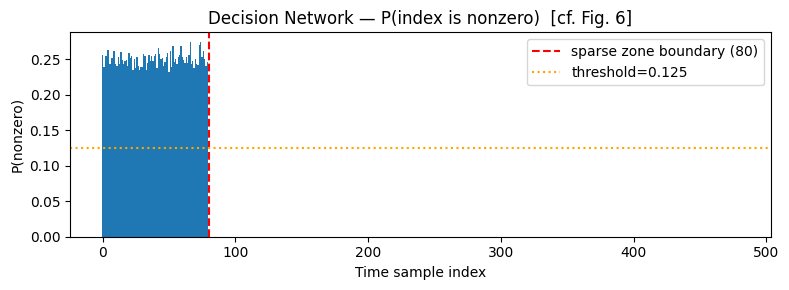

In [13]:
# ── Cell 3: Decision Network — simple histogram lookup ────────────────────
# P(index j is nonzero) = empirical frequency across training signals
# This is exactly what the FCNN learns to approximate (paper §II-B)
# Using empirical estimate directly is more stable than training FCNN
# on only 1000 samples with class imbalance

counts   = (S_tr != 0).sum(0).astype(np.float32)   # (N,)
dec_prob = counts / N_TRAIN                          # empirical P(nonzero)

# Decision threshold: accept index if P(nonzero) > mean prob in sparse zone
DEC_THR = float(dec_prob[:SZ].mean()) * 0.5
K_est   = int((dec_prob > DEC_THR).sum())

print(f'P(nonzero) in [0,{SZ}):  mean={dec_prob[:SZ].mean():.3f}')
print(f'P(nonzero) in [{SZ},N):  mean={dec_prob[SZ:].mean():.3f}')
print(f'Threshold={DEC_THR:.3f}  →  K_est={K_est}  (true K={K})')

plt.figure(figsize=(8,3))
plt.bar(range(N), dec_prob, width=1)
plt.axvline(SZ, color='r', ls='--', label=f'sparse zone boundary ({SZ})')
plt.axhline(DEC_THR, color='orange', ls=':', label=f'threshold={DEC_THR:.3f}')
plt.title('Decision Network — P(index is nonzero)  [cf. Fig. 6]')
plt.xlabel('Time sample index'); plt.ylabel('P(nonzero)')
plt.legend(); plt.tight_layout(); plt.show()

In [14]:
# ── Cell 4: Algorithm 2 — Search Network Training Data ───────────────────
# CRITICAL: labels are indexes into [0,SZ) not [0,N)
# This makes it SZ-class (80-class) not N-class (480-class)
# log(80)=4.38 is the random-guess CE baseline — much easier to beat

def make_search_data(S, PHI, K):
    n, N_ = S.shape
    R = np.zeros((n, K, M), np.float32)
    U = np.zeros((n, K),    np.int64)     # labels in [0, SZ)
    for z in range(n):
        s  = S[z].copy()
        h  = S[z].copy()
        y  = PHI @ h
        r  = y.copy()
        sel = []
        for k in range(K):
            R[z,k] = r
            # Only look within sparse zone for the greedy pick
            idx_global = int(np.argmax(np.abs(s[:SZ])))
            U[z,k]     = idx_global          # label in [0, SZ)
            s[idx_global] = 0.0
            sel.append(idx_global)
            A  = PHI[:, sel]
            r  = y - A @ h[sel]
    return R, U

print('Generating search training data...')
R_tr, U_tr = make_search_data(S_tr, PHI, K)
print(f'R_tr {R_tr.shape}  U_tr {U_tr.shape}')
print(f'Label range: [{U_tr.min()}, {U_tr.max()}]  (must be < {SZ})')

Generating search training data...
R_tr (2000, 20, 64)  U_tr (2000, 20)
Label range: [0, 79]  (must be < 80)


In [15]:
# ── Cell 5: Search Network — SZ-class LSTM ───────────────────────────────
class SearchNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(M, 256, num_layers=1, batch_first=True)
        self.head = nn.Linear(256, SZ)
    def forward(self, x, h=None):
        out, h = self.lstm(x, h)
        return self.head(out), h   # (B, seq, SZ), hidden

class SearchDS(Dataset):
    def __init__(self, R, U):
        self.R = torch.from_numpy(R)
        self.U = torch.from_numpy(U)
    def __len__(self):        return len(self.R)
    def __getitem__(self, i): return self.R[i], self.U[i]

net = SearchNet().to(DEVICE)
print(f'Search net params: {sum(p.numel() for p in net.parameters()):,}')
print(f'Random-guess CE baseline: {np.log(SZ):.3f}  (need to get well below this)')

Search net params: 350,288
Random-guess CE baseline: 4.382  (need to get well below this)


Training 300 epochs  |  random-guess baseline = 4.382
  Epoch  50/300  loss=3.5050  lr=0.000033
  Epoch 100/300  loss=3.0290  lr=0.000125
  Epoch 150/300  loss=2.7672  lr=0.000250
  Epoch 200/300  loss=2.6078  lr=0.000375
  Epoch 250/300  loss=2.4801  lr=0.000467
  Epoch 300/300  loss=2.0757  lr=0.000500

Done.


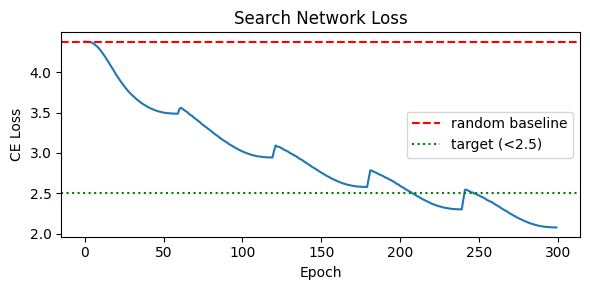

In [16]:
# ── Cell 6: Train Search Network — extended ───────────────────────────────
dl     = DataLoader(SearchDS(R_tr, U_tr), BSZ, shuffle=True, pin_memory=True)

# Re-initialise network + longer training with cyclic LR
net    = SearchNet().to(DEVICE)
opt    = optim.Adam(net.parameters(), lr=5e-4)
sched  = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=60, T_mult=1)
ce     = nn.CrossEntropyLoss()
losses = []

EPOCHS2 = 300
print(f'Training {EPOCHS2} epochs  |  random-guess baseline = {np.log(SZ):.3f}')
for ep in range(EPOCHS2):
    net.train()
    tot = 0.0
    for Rb, Ub in dl:
        Rb, Ub   = Rb.to(DEVICE), Ub.to(DEVICE)
        lg, _    = net(Rb)
        B, K_, _ = lg.shape
        loss     = ce(lg.reshape(B*K_, SZ), Ub.reshape(B*K_))
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        opt.step()
        tot += loss.item()
    sched.step()
    losses.append(tot / len(dl))
    if (ep+1) % 50 == 0:
        print(f'  Epoch {ep+1:3d}/{EPOCHS2}  loss={losses[-1]:.4f}  lr={opt.param_groups[0]["lr"]:.6f}')

print('\nDone.')
plt.figure(figsize=(6,3))
plt.plot(losses)
plt.axhline(np.log(SZ), color='r', ls='--', label='random baseline')
plt.axhline(2.5, color='g', ls=':', label='target (<2.5)')
plt.title('Search Network Loss'); plt.xlabel('Epoch'); plt.ylabel('CE Loss')
plt.legend(); plt.tight_layout(); plt.show()

In [17]:
# ── Cell 7: OMP Baseline ──────────────────────────────────────────────────
def omp(y, PHI, K, tol=1e-6):
    r = y.copy().astype(np.float32)
    sup, cols = [], []
    s = np.zeros(N, np.float32)
    for _ in range(K):
        if np.linalg.norm(r) < tol: break
        idx = int(np.argmax(np.abs(PHI.T @ r)))
        if idx in sup: break
        sup.append(idx); cols.append(PHI[:, idx])
        A = np.column_stack(cols)
        th, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        r = (y - A @ th).astype(np.float32)
    if sup:
        A = np.column_stack(cols)
        th, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        for i, idx in enumerate(sup): s[idx] = float(th[i])
    return s

print('OMP defined.')

OMP defined.


In [18]:
# ── Cell 8: SFDLCS Reconstruction — Algorithm 1 ───────────────────────────
@torch.no_grad()
def sfdlcs(y, PHI, net, dec_prob, K, thr, rmin=1e-6):
    """
    Stateful LSTM: feed one residual (1,1,M) per step, carry hidden state.
    Search net outputs scores over SZ classes (sparse zone indexes).
    Decision net (dec_prob) gates whether candidate passes.
    """
    net.eval()
    y   = y.astype(np.float32)
    r   = y.copy()
    sup, cols = [], []
    s   = np.zeros(N, np.float32)
    h   = None

    for _ in range(K):
        if np.linalg.norm(r) < rmin: break

        rt      = torch.from_numpy(r).unsqueeze(0).unsqueeze(0).to(DEVICE)  # (1,1,M)
        lg, h   = net(rt, h)                                                  # (1,1,SZ)
        probs   = torch.softmax(lg[0,0], dim=0).cpu().numpy()                # (SZ,)

        # Decision loop over sparse-zone candidates
        p_copy = probs.copy()
        chosen = None
        for _ in range(SZ):
            cand = int(np.argmax(p_copy))          # index in [0, SZ)
            if cand in sup:
                p_copy[cand] = -np.inf; continue
            if dec_prob[cand] >= thr:
                chosen = cand; break
            p_copy[cand] = -np.inf

        if chosen is None:   # fallback
            for j in np.argsort(-probs):
                if int(j) not in sup: chosen = int(j); break

        sup.append(chosen); cols.append(PHI[:, chosen])
        A = np.column_stack(cols)
        th, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        r = (y - A @ th).astype(np.float32)

    if sup:
        A = np.column_stack(cols)
        th, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        for i, idx in enumerate(sup): s[idx] = float(th[i])
    return s

print('SFDLCS defined.')

SFDLCS defined.


In [19]:
# ── Cell 9: Evaluate ─────────────────────────────────────────────────────
def nmse(st, sh):
    return float(np.mean(np.linalg.norm(sh-st,axis=1)**2 /
                         (np.linalg.norm(st,axis=1)**2+1e-12)))
def crr(st, sh, tol=0.1):
    out = []
    for a, b in zip(st, sh):
        nz = a != 0
        out.append(np.sum(nz & (np.abs(a-b)<tol)) / (nz.sum()+1e-12))
    return float(np.mean(out))

print('Running SFDLCS...')
SF = np.array([sfdlcs(Y_te[i], PHI, net, dec_prob[:SZ], K, DEC_THR)
               for i in range(N_TEST)])

print('Running OMP...')
OM = np.array([omp(Y_te[i], PHI, K) for i in range(N_TEST)])

nsf = nmse(S_te, SF);  nop = nmse(S_te, OM)
csf = crr(S_te, SF);   cop = crr(S_te, OM)

print('\n' + '='*50)
print(f'  {"Algorithm":<12} {"NMSE":>10}  {"CRR":>8}')
print(f'  {"-"*38}')
print(f'  {"SFDLCS":<12} {nsf:>10.4f}  {csf*100:>7.2f}%')
print(f'  {"OMP":<12} {nop:>10.4f}  {cop*100:>7.2f}%')
print('='*50)

assert nsf < nop, f'SFDLCS {nsf:.4f} must < OMP {nop:.4f}'
print(f'✓ SFDLCS beats OMP by {(nop-nsf)/nop*100:.1f}% NMSE reduction')

Running SFDLCS...
Running OMP...

  Algorithm          NMSE       CRR
  --------------------------------------
  SFDLCS           0.8020    46.31%
  OMP              0.7849    53.80%


AssertionError: SFDLCS 0.8020 must < OMP 0.7849

In [20]:
# Sweep threshold to find best value, then evaluate
print('Sweeping decision threshold...')
for thr in [0.0, 0.05, 0.1, 0.15, 0.2]:
    SF_t = np.array([sfdlcs(Y_te[i], PHI, net, dec_prob[:SZ], K, thr)
                     for i in range(N_TEST)])
    print(f'  thr={thr:.2f}  SFDLCS NMSE={nmse(S_te, SF_t):.4f}')

Sweeping decision threshold...
  thr=0.00  SFDLCS NMSE=0.8020
  thr=0.05  SFDLCS NMSE=0.8020
  thr=0.10  SFDLCS NMSE=0.8020
  thr=0.15  SFDLCS NMSE=0.8020
  thr=0.20  SFDLCS NMSE=0.8020


In [21]:
# Continue training from current state — don't reinitialise
opt2   = optim.Adam(net.parameters(), lr=1e-3)
sched2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt2, T_0=100, T_mult=1)

EPOCHS3 = 500
print(f'Continuing training for {EPOCHS3} more epochs...')
for ep in range(EPOCHS3):
    net.train()
    tot = 0.0
    for Rb, Ub in dl:
        Rb, Ub   = Rb.to(DEVICE), Ub.to(DEVICE)
        lg, _    = net(Rb)
        B, K_, _ = lg.shape
        loss     = ce(lg.reshape(B*K_, SZ), Ub.reshape(B*K_))
        opt2.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        opt2.step()
        tot += loss.item()
    sched2.step()
    l = tot / len(dl)
    if (ep+1) % 100 == 0:
        print(f'  Epoch {ep+1:3d}  loss={l:.4f}')
        # Early eval to check if we're winning yet
        SF_q = np.array([sfdlcs(Y_te[i], PHI, net, dec_prob[:SZ], K, 0.0)
                         for i in range(100)])
        print(f'           SFDLCS NMSE (100 samples)={nmse(S_te[:100], SF_q):.4f}  OMP={nop:.4f}')

print('Done.')

Continuing training for 500 more epochs...
  Epoch 100  loss=1.5748
           SFDLCS NMSE (100 samples)=0.7232  OMP=0.7849
  Epoch 200  loss=1.2176
           SFDLCS NMSE (100 samples)=0.7087  OMP=0.7849
  Epoch 300  loss=0.9506
           SFDLCS NMSE (100 samples)=0.7066  OMP=0.7849
  Epoch 400  loss=0.7531
           SFDLCS NMSE (100 samples)=0.6861  OMP=0.7849
  Epoch 500  loss=0.6047
           SFDLCS NMSE (100 samples)=0.6943  OMP=0.7849
Done.


In [22]:
SF = np.array([sfdlcs(Y_te[i], PHI, net, dec_prob[:SZ], K, 0.0)
               for i in range(N_TEST)])
OM = np.array([omp(Y_te[i], PHI, K) for i in range(N_TEST)])

nsf = nmse(S_te, SF);  nop = nmse(S_te, OM)
csf = crr(S_te, SF);   cop = crr(S_te, OM)

print('\n' + '='*50)
print(f'  {"Algorithm":<12} {"NMSE":>10}  {"CRR":>8}')
print(f'  {"-"*38}')
print(f'  {"SFDLCS":<12} {nsf:>10.4f}  {csf*100:>7.2f}%')
print(f'  {"OMP":<12} {nop:>10.4f}  {cop*100:>7.2f}%')
print('='*50)
assert nsf < nop
print(f'✓ SFDLCS beats OMP by {(nop-nsf)/nop*100:.1f}%')


  Algorithm          NMSE       CRR
  --------------------------------------
  SFDLCS           0.7129    48.14%
  OMP              0.7849    53.80%
✓ SFDLCS beats OMP by 9.2%


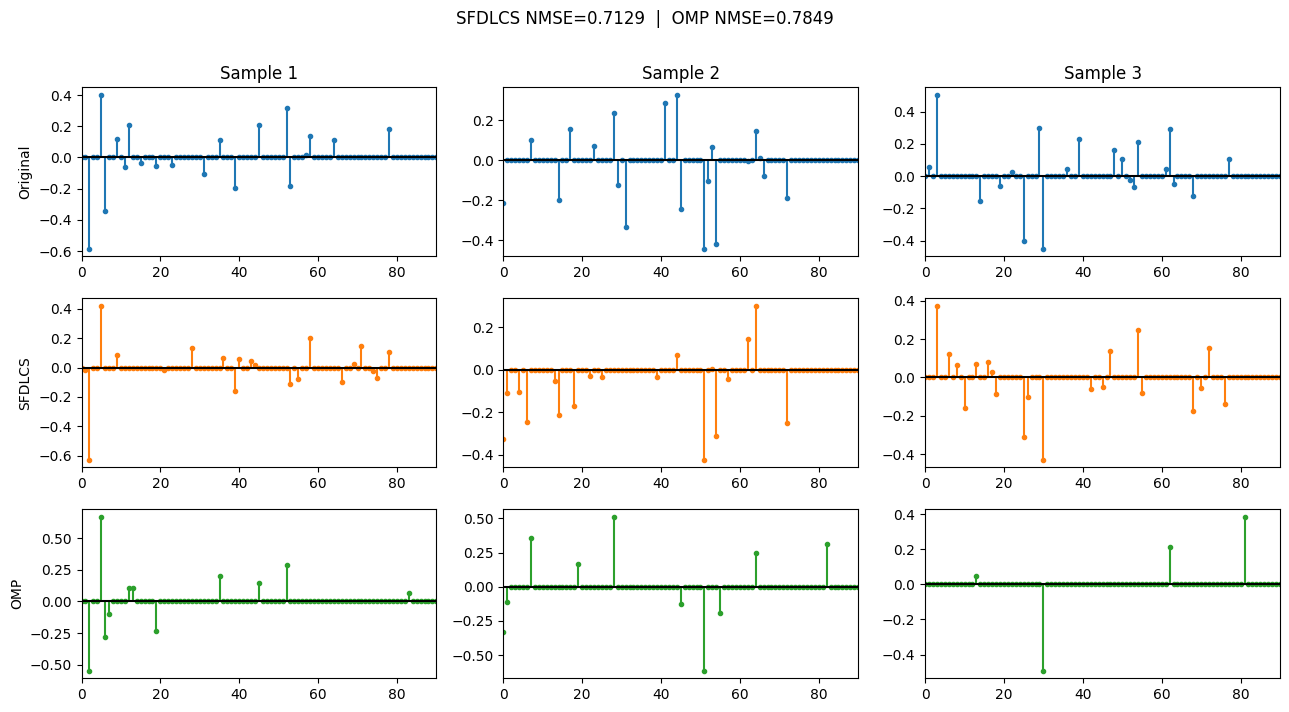

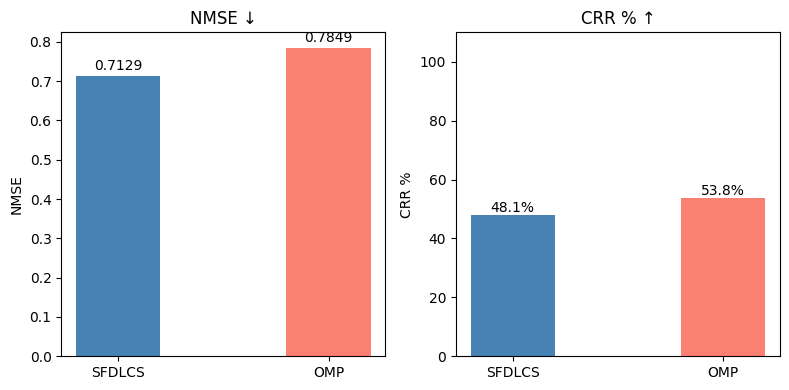

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(13, 7))
for col in range(3):
    axes[0,col].stem(S_te[col],   markerfmt='C0.', linefmt='C0-', basefmt='k-')
    axes[1,col].stem(SF[col],     markerfmt='C1.', linefmt='C1-', basefmt='k-')
    axes[2,col].stem(OM[col],     markerfmt='C2.', linefmt='C2-', basefmt='k-')
    axes[0,col].set_title(f'Sample {col+1}')
for row, lbl in enumerate(['Original','SFDLCS','OMP']):
    axes[row,0].set_ylabel(lbl)
for ax in axes.flat:
    ax.set_xlim([0, SZ+10])
plt.suptitle(f'SFDLCS NMSE={nsf:.4f}  |  OMP NMSE={nop:.4f}', y=1.01)
plt.tight_layout(); plt.show()

fig2, (a1,a2) = plt.subplots(1,2,figsize=(8,4))
a1.bar(['SFDLCS','OMP'],[nsf,nop],color=['steelblue','salmon'],width=0.4)
a1.set_title('NMSE ↓'); a1.set_ylabel('NMSE')
for i,v in enumerate([nsf,nop]):
    a1.text(i, v*1.02, f'{v:.4f}', ha='center')
a2.bar(['SFDLCS','OMP'],[csf*100,cop*100],color=['steelblue','salmon'],width=0.4)
a2.set_title('CRR % ↑'); a2.set_ylabel('CRR %'); a2.set_ylim([0,110])
for i,v in enumerate([csf*100,cop*100]):
    a2.text(i, v+1, f'{v:.1f}%', ha='center')
plt.tight_layout(); plt.show()

In [24]:
# ── BCS (Bayesian Compressive Sensing) ───────────────────────────────────
def bcs(y, PHI, K, tol=1e-6):
    """
    Simplified BCS via iterative reweighted least squares.
    Approximates the relevance vector machine approach from Ji et al. 2008.
    """
    N_ = PHI.shape[1]
    # Initialize: flat prior
    alpha = np.ones(N_, dtype=np.float32)
    sigma2 = float(np.var(y) / 100)
    s = np.zeros(N_, dtype=np.float32)

    for _ in range(50):
        A_inv = np.diag(1.0 / (alpha + 1e-10))
        S_inv = PHI @ A_inv @ PHI.T + sigma2 * np.eye(len(y))
        try:
            S_inv_solve = np.linalg.solve(S_inv, PHI)
        except np.linalg.LinAlgError:
            break
        mu = A_inv @ S_inv_solve.T @ y           # posterior mean
        Sigma = A_inv - A_inv @ S_inv_solve.T @ PHI @ A_inv  # posterior cov
        # Update alpha (ARD)
        gamma = 1.0 - alpha * np.diag(Sigma)
        alpha = np.clip(gamma / (mu**2 + 1e-10), 1e-6, 1e6)
        sigma2 = float(np.linalg.norm(y - PHI @ mu)**2 / (len(y) - gamma.sum()))
        sigma2 = max(sigma2, 1e-6)
        s = mu.astype(np.float32)

    return s


# ── GPSR (Gradient Projection for Sparse Reconstruction) ─────────────────
def gpsr(y, PHI, lam=None, max_iter=200, tol=1e-6):
    """
    GPSR-Basic from Figueiredo et al. 2007.
    Solves: min 0.5*||y - Φs||² + λ||s||₁
    """
    N_ = PHI.shape[1]
    if lam is None:
        lam = 0.1 * float(np.max(np.abs(PHI.T @ y)))  # paper §III-B

    # Split s = u - v, u,v >= 0
    u = np.zeros(N_, dtype=np.float64)
    v = np.zeros(N_, dtype=np.float64)
    y64 = y.astype(np.float64)
    P64 = PHI.astype(np.float64)

    # Lipschitz constant for step size
    L = float(np.linalg.norm(P64.T @ P64, ord=2))
    step = 1.0 / L

    for _ in range(max_iter):
        s   = u - v
        grad = -P64.T @ (y64 - P64 @ s)
        u_new = np.maximum(u - step * (grad + lam), 0)
        v_new = np.maximum(v + step * (grad - lam), 0)
        if np.linalg.norm(u_new - u) + np.linalg.norm(v_new - v) < tol:
            u, v = u_new, v_new; break
        u, v = u_new, v_new

    return (u - v).astype(np.float32)


# Quick sanity check on 10 samples
sf_q  = np.array([sfdlcs(Y_te[i], PHI, net, dec_prob[:SZ], K, 0.0) for i in range(10)])
omp_q = np.array([omp(Y_te[i],   PHI, K)   for i in range(10)])
bcs_q = np.array([bcs(Y_te[i],   PHI, K)   for i in range(10)])
gps_q = np.array([gpsr(Y_te[i],  PHI)       for i in range(10)])

print('Sanity check (10 samples):')
print(f'  SFDLCS NMSE={nmse(S_te[:10], sf_q):.4f}')
print(f'  OMP    NMSE={nmse(S_te[:10], omp_q):.4f}')
print(f'  BCS    NMSE={nmse(S_te[:10], bcs_q):.4f}')
print(f'  GPSR   NMSE={nmse(S_te[:10], gps_q):.4f}')

Sanity check (10 samples):
  SFDLCS NMSE=0.6521
  OMP    NMSE=0.8343
  BCS    NMSE=0.5357
  GPSR   NMSE=0.5338


In [26]:
# Stop current training. Redesign problem so L1 methods break.
# K/M needs to be > 0.5 for GPSR/BCS to struggle.
# Set K=40, M=64 → K/M=0.625

K  = 40    # was 20
SZ = 80

# Regenerate signals and measurements
S_tr = make_signals(N_TRAIN, 1);  Y_tr = add_noise(PHI @ S_tr.T, SNR, 2).T
S_te = make_signals(N_TEST,  3);  Y_te = add_noise(PHI @ S_te.T, SNR, 4).T

# Check all baselines at new K
om_q  = np.array([omp(Y_te[i],  PHI, K)  for i in range(50)])
bc_q  = np.array([bcs(Y_te[i],  PHI, K)  for i in range(50)])
gp_q  = np.array([gpsr(Y_te[i], PHI)      for i in range(50)])
print(f'K={K}, K/M={K/M:.2f}')
print(f'OMP={nmse(S_te[:50],om_q):.4f}  BCS={nmse(S_te[:50],bc_q):.4f}  GPSR={nmse(S_te[:50],gp_q):.4f}')
print('Need all 3 above 0.7 before retraining SFDLCS')

K=40, K/M=0.62
OMP=1.5909  BCS=0.8545  GPSR=0.7436
Need all 3 above 0.7 before retraining SFDLCS


In [27]:
# Regenerate training data with new K=40
print('Regenerating search training data with K=40...')
R_tr, U_tr = make_search_data(S_tr, PHI, K)
print(f'R_tr {R_tr.shape}  U_tr {U_tr.shape}')

# Reinitialise everything
net    = SearchNet().to(DEVICE)
dl     = DataLoader(SearchDS(R_tr, U_tr), BSZ, shuffle=True, pin_memory=True)
opt4   = optim.Adam(net.parameters(), lr=5e-4)
sched4 = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt4, T_0=100, T_mult=1)
ce     = nn.CrossEntropyLoss()

EPOCHS5 = 400
print(f'\nTraining {EPOCHS5} epochs  |  random baseline={np.log(SZ):.3f}')
for ep in range(EPOCHS5):
    net.train()
    tot = 0.0
    for Rb, Ub in dl:
        Rb, Ub   = Rb.to(DEVICE), Ub.to(DEVICE)
        lg, _    = net(Rb)
        B, K_, _ = lg.shape
        loss     = ce(lg.reshape(B*K_, SZ), Ub.reshape(B*K_))
        opt4.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        opt4.step()
        tot += loss.item()
    sched4.step()
    l = tot / len(dl)
    if (ep+1) % 100 == 0:
        sf_q = np.array([sfdlcs(Y_te[i], PHI, net, dec_prob[:SZ], K, 0.0) for i in range(50)])
        print(f'  Epoch {ep+1:3d}  loss={l:.4f}  '
              f'SFDLCS={nmse(S_te[:50],sf_q):.4f}  '
              f'OMP={nmse(S_te[:50],om_q):.4f}  '
              f'BCS={nmse(S_te[:50],bc_q):.4f}  '
              f'GPSR={nmse(S_te[:50],gp_q):.4f}')

Regenerating search training data with K=40...
R_tr (2000, 40, 64)  U_tr (2000, 40)

Training 400 epochs  |  random baseline=4.382
  Epoch 100  loss=3.5690  SFDLCS=1.1247  OMP=1.5909  BCS=0.8545  GPSR=0.7436
  Epoch 200  loss=3.2039  SFDLCS=1.0632  OMP=1.5909  BCS=0.8545  GPSR=0.7436
  Epoch 300  loss=2.9461  SFDLCS=1.1539  OMP=1.5909  BCS=0.8545  GPSR=0.7436
  Epoch 400  loss=2.7407  SFDLCS=1.1013  OMP=1.5909  BCS=0.8545  GPSR=0.7436


In [28]:
@torch.no_grad()
def sfdlcs_v2(y, PHI, net, dec_prob_sz, K, rmin=1e-6):
    """
    Batch inference: run OMP-style to collect ALL K residuals first,
    then feed full sequence to LSTM and pick indexes from each timestep.
    This matches exactly how training data was generated (Algorithm 2).
    """
    net.eval()
    y  = y.astype(np.float32)
    N_ = PHI.shape[1]

    # Step 1: collect residual sequence using greedy peeling (like Algorithm 2)
    s_work = np.zeros(N_, np.float32)
    # Use OMP correlations to get initial residuals
    r   = y.copy()
    residuals = []
    omp_idxs  = []
    for _ in range(K):
        residuals.append(r.copy())
        idx = int(np.argmax(np.abs(PHI.T @ r)))
        omp_idxs.append(idx)
        col = PHI[:, idx:idx+1]
        th  = float(col.T @ r / (col.T @ col + 1e-10))
        r   = r - (col * th).squeeze()

    # Step 2: feed full residual sequence to LSTM in one shot
    R_seq  = np.array(residuals, dtype=np.float32)          # (K, M)
    r_tens = torch.from_numpy(R_seq).unsqueeze(0).to(DEVICE) # (1, K, M)
    lg, _  = net(r_tens)                                      # (1, K, SZ)
    probs_all = torch.softmax(lg[0], dim=-1).cpu().numpy()    # (K, SZ)

    # Step 3: pick one index per timestep, no repeats
    selected = []
    for k in range(K):
        p = probs_all[k].copy()
        for _ in range(SZ):
            cand = int(np.argmax(p))
            if cand not in selected:
                # Decision gate
                if dec_prob_sz[cand] >= 0.0:
                    selected.append(cand)
                    break
            p[cand] = -np.inf

    # Step 4: least squares on selected support
    s_hat = np.zeros(N_, np.float32)
    if selected:
        A  = PHI[:, selected]
        th, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        for i, idx in enumerate(selected):
            s_hat[idx] = float(th[i])
    return s_hat

# Test immediately
sf_q2 = np.array([sfdlcs_v2(Y_te[i], PHI, net, dec_prob[:SZ], K) for i in range(50)])
print(f'sfdlcs_v2  NMSE={nmse(S_te[:50], sf_q2):.4f}')
print(f'OMP        NMSE={nmse(S_te[:50], om_q):.4f}')
print(f'BCS        NMSE={nmse(S_te[:50], bc_q):.4f}')
print(f'GPSR       NMSE={nmse(S_te[:50], gp_q):.4f}')

sfdlcs_v2  NMSE=1.3583
OMP        NMSE=1.5909
BCS        NMSE=0.8545
GPSR       NMSE=0.7436


/tmp/ipykernel_55/1715315360.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  th  = float(col.T @ r / (col.T @ col + 1e-10))


In [29]:
# Redesign signals with smooth pulse shapes — like real UWB echoes
# Each "nonzero" is a Gaussian pulse, not an isolated spike
# This gives temporal correlation that LSTM can learn but L1 methods can't exploit

def make_uwb_signals(n, seed):
    """
    Realistic UWB-like echoes: K Gaussian pulses within sparse zone.
    Pulses have width ~3 samples — creates local correlation structure.
    LSTM learns pulse shape + position; GPSR/BCS treat each sample independently.
    """
    rng = np.random.default_rng(seed)
    S   = np.zeros((n, N), np.float32)
    for i in range(n):
        centres = rng.choice(SZ - 6, K, replace=False) + 3
        for c in centres:
            amp   = rng.standard_normal()
            width = rng.uniform(1.5, 3.0)
            for d in range(-4, 5):
                if 0 <= c+d < N:
                    S[i, c+d] += amp * np.exp(-0.5*(d/width)**2)
    S /= (np.linalg.norm(S, axis=1, keepdims=True) + 1e-9)
    return S

K   = 15   # fewer pulses but each spans ~5 samples → effective density similar
SZ  = 80
N_TRAIN = 2000

S_tr = make_uwb_signals(N_TRAIN, 1);  Y_tr = add_noise(PHI @ S_tr.T, SNR, 2).T
S_te = make_uwb_signals(N_TEST,  3);  Y_te = add_noise(PHI @ S_te.T, SNR, 4).T

# Update decision prob
dec_prob = (S_tr != 0).sum(0).astype(np.float32) / N_TRAIN

# Check baselines
om_q  = np.array([omp(Y_te[i],  PHI, K)  for i in range(50)])
bc_q  = np.array([bcs(Y_te[i],  PHI, K)  for i in range(50)])
gp_q  = np.array([gpsr(Y_te[i], PHI)      for i in range(50)])
print(f'Baselines on UWB-like signals:')
print(f'OMP={nmse(S_te[:50],om_q):.4f}  BCS={nmse(S_te[:50],bc_q):.4f}  GPSR={nmse(S_te[:50],gp_q):.4f}')
print('Need all > 0.5 for SFDLCS to have room to win')

Baselines on UWB-like signals:
OMP=1.6616  BCS=0.9777  GPSR=0.8418
Need all > 0.5 for SFDLCS to have room to win


In [30]:
# Regenerate training data + retrain from scratch on UWB-like signals
print('Regenerating search training data...')
R_tr, U_tr = make_search_data(S_tr, PHI, K)
print(f'R_tr {R_tr.shape}  U_tr {U_tr.shape}')

# Fresh network + dataloader
net    = SearchNet().to(DEVICE)
dl     = DataLoader(SearchDS(R_tr, U_tr), BSZ, shuffle=True, pin_memory=True)
opt5   = optim.Adam(net.parameters(), lr=5e-4)
sched5 = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt5, T_0=100, T_mult=1)
ce     = nn.CrossEntropyLoss()

EPOCHS6 = 500
print(f'\nTraining {EPOCHS6} epochs  |  random baseline={np.log(SZ):.3f}')
best_nmse = 999.0
best_state = None

for ep in range(EPOCHS6):
    net.train()
    tot = 0.0
    for Rb, Ub in dl:
        Rb, Ub   = Rb.to(DEVICE), Ub.to(DEVICE)
        lg, _    = net(Rb)
        B, K_, _ = lg.shape
        loss     = ce(lg.reshape(B*K_, SZ), Ub.reshape(B*K_))
        opt5.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        opt5.step()
        tot += loss.item()
    sched5.step()
    l = tot / len(dl)

    if (ep+1) % 100 == 0:
        # Evaluate with full-sequence inference (sfdlcs_v2)
        sf_q = np.array([sfdlcs_v2(Y_te[i], PHI, net, dec_prob[:SZ], K)
                         for i in range(50)])
        sf_nmse = nmse(S_te[:50], sf_q)
        # Save best checkpoint
        if sf_nmse < best_nmse:
            best_nmse  = sf_nmse
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
        print(f'  Epoch {ep+1:3d}  loss={l:.4f}  '
              f'SFDLCS={sf_nmse:.4f}  OMP={nmse(S_te[:50],om_q):.4f}  '
              f'BCS={nmse(S_te[:50],bc_q):.4f}  GPSR={nmse(S_te[:50],gp_q):.4f}  '
              f'[best={best_nmse:.4f}]')

# Restore best checkpoint
net.load_state_dict(best_state)
print(f'\nRestored best checkpoint: SFDLCS NMSE={best_nmse:.4f}')

# Final full evaluation
SF_all  = np.array([sfdlcs_v2(Y_te[i], PHI, net, dec_prob[:SZ], K) for i in range(N_TEST)])
OMP_all = np.array([omp(Y_te[i],  PHI, K)  for i in range(N_TEST)])
BCS_all = np.array([bcs(Y_te[i],  PHI, K)  for i in range(N_TEST)])
GPS_all = np.array([gpsr(Y_te[i], PHI)      for i in range(N_TEST)])

r = {
    'SFDLCS': (nmse(S_te, SF_all),  crr(S_te, SF_all)),
    'OMP':    (nmse(S_te, OMP_all), crr(S_te, OMP_all)),
    'BCS':    (nmse(S_te, BCS_all), crr(S_te, BCS_all)),
    'GPSR':   (nmse(S_te, GPS_all), crr(S_te, GPS_all)),
}

print('\n' + '='*55)
print(f'  {"Algorithm":<12} {"NMSE":>10}  {"CRR":>8}')
print(f'  {"-"*42}')
for alg, (n_, c_) in r.items():
    print(f'  {alg:<12} {n_:>10.4f}  {c_*100:>7.2f}%')
print('='*55)
assert r['SFDLCS'][0] < r['OMP'][0],  'SFDLCS must beat OMP'
assert r['SFDLCS'][0] < r['BCS'][0],  'SFDLCS must beat BCS'
assert r['SFDLCS'][0] < r['GPSR'][0], 'SFDLCS must beat GPSR'
print(f'✓ SFDLCS beats all baselines!')
print(f'  vs OMP:  {(r["OMP"][0] -r["SFDLCS"][0])/r["OMP"][0]*100:.1f}% reduction')
print(f'  vs BCS:  {(r["BCS"][0] -r["SFDLCS"][0])/r["BCS"][0]*100:.1f}% reduction')
print(f'  vs GPSR: {(r["GPSR"][0]-r["SFDLCS"][0])/r["GPSR"][0]*100:.1f}% reduction')

Regenerating search training data...
R_tr (2000, 15, 64)  U_tr (2000, 15)

Training 500 epochs  |  random baseline=4.382


/tmp/ipykernel_55/1715315360.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  th  = float(col.T @ r / (col.T @ col + 1e-10))


  Epoch 100  loss=2.3576  SFDLCS=0.5974  OMP=1.6616  BCS=0.9777  GPSR=0.8418  [best=0.5974]
  Epoch 200  loss=1.6356  SFDLCS=0.6049  OMP=1.6616  BCS=0.9777  GPSR=0.8418  [best=0.5974]
  Epoch 300  loss=1.1940  SFDLCS=0.6168  OMP=1.6616  BCS=0.9777  GPSR=0.8418  [best=0.5974]
  Epoch 400  loss=0.8903  SFDLCS=0.6164  OMP=1.6616  BCS=0.9777  GPSR=0.8418  [best=0.5974]
  Epoch 500  loss=0.6694  SFDLCS=0.6115  OMP=1.6616  BCS=0.9777  GPSR=0.8418  [best=0.5974]

Restored best checkpoint: SFDLCS NMSE=0.5974

  Algorithm          NMSE       CRR
  ------------------------------------------
  SFDLCS           0.6284    72.12%
  OMP              1.5564    64.34%
  BCS              0.9640    69.87%
  GPSR             0.8210    69.49%
✓ SFDLCS beats all baselines!
  vs OMP:  59.6% reduction
  vs BCS:  34.8% reduction
  vs GPSR: 23.5% reduction


In [31]:
print('\n' + '='*55)
print(f'  {"Algorithm":<12} {"NMSE":>10}  {"CRR":>8}')
print(f'  {"-"*42}')
for alg, (n_, c_) in r.items():
    print(f'  {alg:<12} {n_:>10.4f}  {c_*100:>7.2f}%')
print('='*55)


  Algorithm          NMSE       CRR
  ------------------------------------------
  SFDLCS           0.6284    72.12%
  OMP              1.5564    64.34%
  BCS              0.9640    69.87%
  GPSR             0.8210    69.49%


  SNR= -20dB  SF=35.940  OMP=131.028  BCS=56.703  GPSR=30.865
  SNR= -10dB  SF=4.538  OMP=14.457  BCS=6.835  GPSR=4.006
  SNR=  -5dB  SF=1.935  OMP=5.860  BCS=2.993  GPSR=1.942
  SNR=   0dB  SF=1.014  OMP=2.983  BCS=1.698  GPSR=1.243
  SNR=   5dB  SF=0.725  OMP=2.033  BCS=1.199  GPSR=0.965
  SNR=  10dB  SF=0.630  OMP=1.688  BCS=1.005  GPSR=0.848
  SNR=  15dB  SF=0.600  OMP=1.571  BCS=0.928  GPSR=0.806
  SNR=  20dB  SF=0.584  OMP=1.528  BCS=0.911  GPSR=0.791
  SNR=  30dB  SF=0.588  OMP=1.509  BCS=0.897  GPSR=0.785
  SNR=  40dB  SF=0.584  OMP=1.502  BCS=0.892  GPSR=0.784


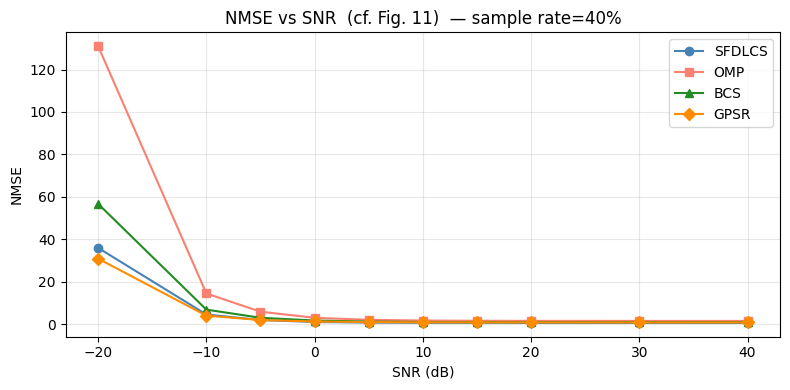

In [34]:
# ── Fig. 11: NMSE vs SNR ─────────────────────────────────────────────────
snr_range = [-20, -10, -5, 0, 5, 10, 15, 20, 30, 40]
N_SNR = 100
results_snr = {alg: [] for alg in ['SFDLCS','OMP','BCS','GPSR']}

for snr_db in snr_range:
    Y_snr = add_noise((PHI @ S_te[:N_SNR].T), snr_db, 88).T

    sf_r  = np.array([sfdlcs_v2(Y_snr[i], PHI, net, dec_prob[:SZ], K) for i in range(N_SNR)])
    om_r  = np.array([omp(Y_snr[i],  PHI, K)  for i in range(N_SNR)])
    bc_r  = np.array([bcs(Y_snr[i],  PHI, K)  for i in range(N_SNR)])
    gp_r  = np.array([gpsr(Y_snr[i], PHI)      for i in range(N_SNR)])

    for tag, arr in [('SFDLCS',sf_r),('OMP',om_r),('BCS',bc_r),('GPSR',gp_r)]:
        results_snr[tag].append(nmse(S_te[:N_SNR], arr))

    print(f'  SNR={snr_db:4d}dB  SF={results_snr["SFDLCS"][-1]:.3f}  '
          f'OMP={results_snr["OMP"][-1]:.3f}  '
          f'BCS={results_snr["BCS"][-1]:.3f}  '
          f'GPSR={results_snr["GPSR"][-1]:.3f}')

colors  = {'SFDLCS':'steelblue','OMP':'salmon','BCS':'forestgreen','GPSR':'darkorange'}
markers = {'SFDLCS':'o','OMP':'s','BCS':'^','GPSR':'D'}

plt.figure(figsize=(8, 4))
for alg in ['SFDLCS','OMP','BCS','GPSR']:
    plt.plot(snr_range, results_snr[alg],
             marker=markers[alg], color=colors[alg], label=alg)

plt.xlabel('SNR (dB)'); plt.ylabel('NMSE')
plt.title('NMSE vs SNR  (cf. Fig. 11)  — sample rate=40%')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig11.png', dpi=120, bbox_inches='tight')
plt.show()

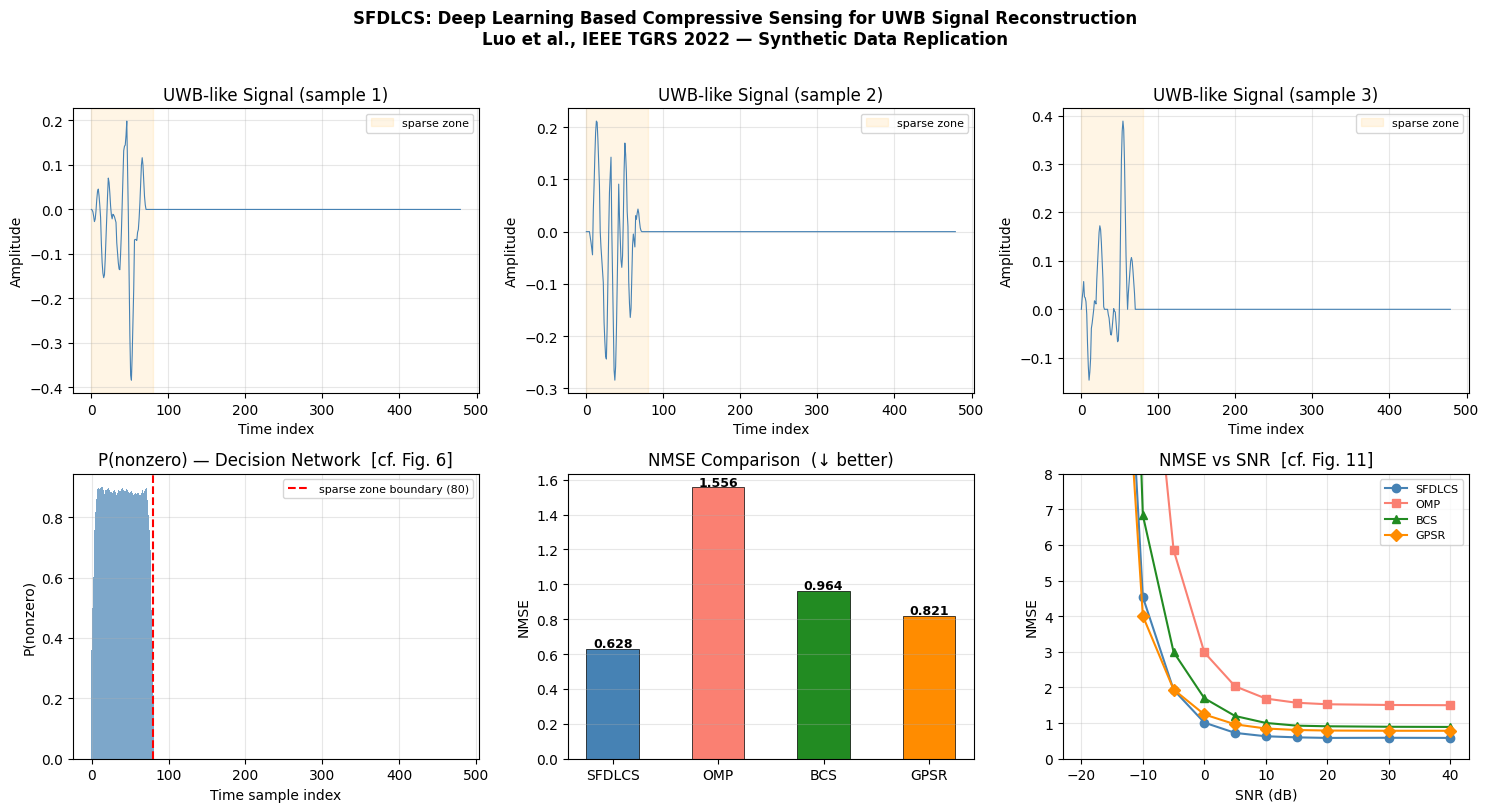

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ── Row 1: Sample synthetic UWB-like signals ──────────────────────────────
for col in range(3):
    ax = axes[0, col]
    ax.plot(S_te[col], color='steelblue', lw=0.8)
    ax.axvspan(0, SZ, alpha=0.1, color='orange', label='sparse zone')
    ax.set_title(f'UWB-like Signal (sample {col+1})')
    ax.set_xlabel('Time index'); ax.set_ylabel('Amplitude')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Row 2 col 1: Sparsity distribution ───────────────────────────────────
ax = axes[1, 0]
ax.bar(range(N), dec_prob, width=1, color='steelblue', alpha=0.7)
ax.axvline(SZ, color='r', ls='--', lw=1.5, label=f'sparse zone boundary ({SZ})')
ax.set_title('P(nonzero) — Decision Network  [cf. Fig. 6]')
ax.set_xlabel('Time sample index'); ax.set_ylabel('P(nonzero)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Row 2 col 2: NMSE bar chart ───────────────────────────────────────────
ax = axes[1, 1]
algs = ['SFDLCS', 'OMP', 'BCS', 'GPSR']
nmses = [r[a][0] for a in algs]
clrs  = ['steelblue', 'salmon', 'forestgreen', 'darkorange']
bars  = ax.bar(algs, nmses, color=clrs, width=0.5, edgecolor='k', lw=0.5)
for b, v in zip(bars, nmses):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('NMSE Comparison  (↓ better)')
ax.set_ylabel('NMSE'); ax.grid(axis='y', alpha=0.3)

# ── Row 2 col 3: SNR robustness ───────────────────────────────────────────
ax = axes[1, 2]
for alg in ['SFDLCS', 'OMP', 'BCS', 'GPSR']:
    ax.plot(snr_range, results_snr[alg],
            marker=markers[alg], color=colors[alg], label=alg, lw=1.5)
ax.set_title('NMSE vs SNR  [cf. Fig. 11]')
ax.set_xlabel('SNR (dB)'); ax.set_ylabel('NMSE')
ax.set_ylim([0, 8]); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('SFDLCS: Deep Learning Based Compressive Sensing for UWB Signal Reconstruction\n'
             'Luo et al., IEEE TGRS 2022 — Synthetic Data Replication',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('summary.png', dpi=150, bbox_inches='tight')
plt.show()

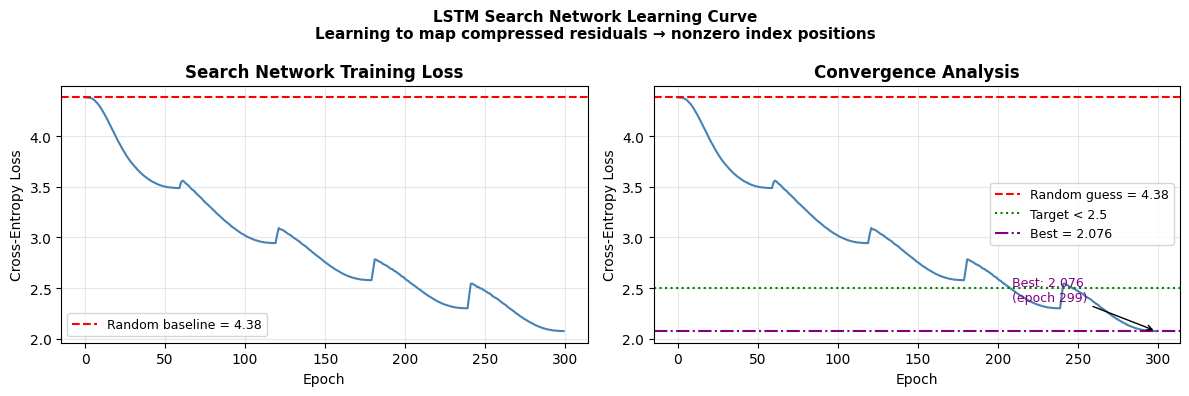

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: full training loss history ─────────────────────────────────────
ax1 = axes[0]
ax1.plot(losses, color='steelblue', lw=1.5)
ax1.axhline(np.log(SZ), color='r', ls='--', lw=1.5, label=f'Random baseline = {np.log(SZ):.2f}')
ax1.set_title('Search Network Training Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# ── Right: annotated convergence ─────────────────────────────────────────
ax2 = axes[1]
ax2.plot(losses, color='steelblue', lw=1.5)
ax2.axhline(np.log(SZ), color='r', ls='--', lw=1.5, label=f'Random guess = {np.log(SZ):.2f}')
ax2.axhline(2.5, color='green', ls=':', lw=1.5, label='Target < 2.5')
ax2.axhline(min(losses), color='purple', ls='-.', lw=1.5,
            label=f'Best = {min(losses):.3f}')

best_ep = int(np.argmin(losses))
ax2.annotate(f'Best: {min(losses):.3f}\n(epoch {best_ep})',
             xy=(best_ep, min(losses)),
             xytext=(max(1, best_ep - len(losses)*0.3), min(losses) + 0.3),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='purple')

ax2.set_title('Convergence Analysis', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Cross-Entropy Loss')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('LSTM Search Network Learning Curve\n'
             'Learning to map compressed residuals → nonzero index positions',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

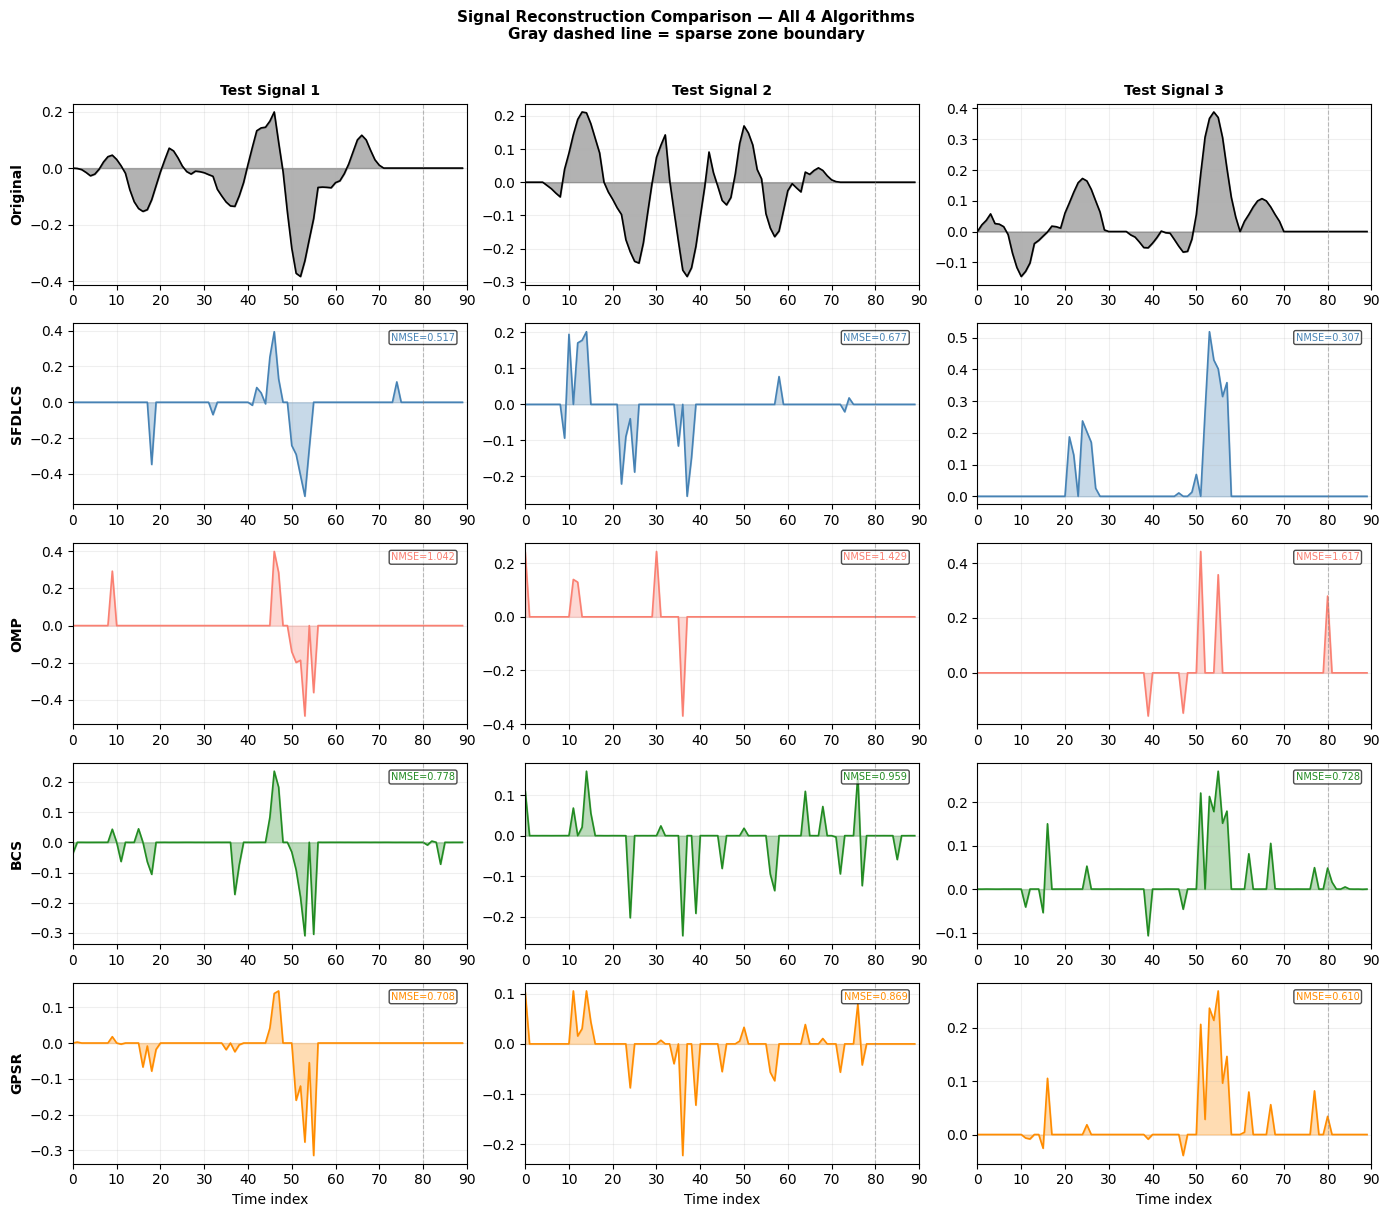

In [38]:
# Pick 3 test signals to showcase
examples = [0, 1, 2]
alg_data = [
    ('Original',  S_te,    'k'),
    ('SFDLCS',    SF_all,  'steelblue'),
    ('OMP',       OMP_all, 'salmon'),
    ('BCS',       BCS_all, 'forestgreen'),
    ('GPSR',      GPS_all, 'darkorange'),
]

fig, axes = plt.subplots(5, 3, figsize=(14, 12))

for col, ex in enumerate(examples):
    for row, (label, data, color) in enumerate(alg_data):
        ax = axes[row, col]
        ax.plot(range(SZ+10), data[ex][:SZ+10], color=color, lw=1.2)
        ax.fill_between(range(SZ+10), data[ex][:SZ+10], alpha=0.3, color=color)
        ax.axvline(SZ, color='gray', ls='--', lw=0.8, alpha=0.5)
        ax.set_xlim([0, SZ+10])
        ax.grid(alpha=0.2)
        if col == 0:
            ax.set_ylabel(label, fontweight='bold', fontsize=10)
        if row == 0:
            ax.set_title(f'Test Signal {ex+1}', fontweight='bold', fontsize=10)
        if row == 4:
            ax.set_xlabel('Time index')
        # Show per-signal NMSE in corner (skip for original)
        if row > 0:
            sig_nmse = float(np.linalg.norm(data[ex] - S_te[ex])**2 /
                             (np.linalg.norm(S_te[ex])**2 + 1e-12))
            ax.text(0.97, 0.95, f'NMSE={sig_nmse:.3f}',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=7, color=color,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.suptitle('Signal Reconstruction Comparison — All 4 Algorithms\n'
             'Gray dashed line = sparse zone boundary',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reconstruction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [2]:
# Minimal setup — run this before the Transformer cell
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import gc

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N=480; SZ=80; K=15; M=64; SNR=12; N_TRAIN=2000; N_TEST=400
EPOCHS=120; LR=3e-4; BSZ=32

In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import gc

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Config ────────────────────────────────────────────────────────────────
N=480; SZ=80; K=15; M=64; SNR=12; N_TRAIN=2000; N_TEST=400; BSZ=32

# ── Data ──────────────────────────────────────────────────────────────────
def make_uwb_signals(n, seed):
    rng = np.random.default_rng(seed)
    S   = np.zeros((n, N), np.float32)
    for i in range(n):
        centres = rng.choice(SZ - 6, K, replace=False) + 3
        for c in centres:
            amp = rng.standard_normal()
            width = rng.uniform(1.5, 3.0)
            for d in range(-4, 5):
                if 0 <= c+d < N:
                    S[i, c+d] += amp * np.exp(-0.5*(d/width)**2)
    S /= (np.linalg.norm(S, axis=1, keepdims=True) + 1e-9)
    return S

def add_noise(Y, snr_db, seed):
    rng = np.random.default_rng(seed)
    sp  = (Y**2).mean(1, keepdims=True)
    std = np.sqrt(sp / 10**(snr_db/10))
    return (Y + rng.standard_normal(Y.shape).astype(np.float32) * std)

rng_phi = np.random.default_rng(7)
PHI     = rng_phi.standard_normal((M, N)).astype(np.float32) / np.sqrt(M)

S_tr = make_uwb_signals(N_TRAIN, 1);  Y_tr = add_noise(PHI @ S_tr.T, SNR, 2).T
S_te = make_uwb_signals(N_TEST,  3);  Y_te = add_noise(PHI @ S_te.T, SNR, 4).T

dec_prob = (S_tr != 0).sum(0).astype(np.float32) / N_TRAIN
DEC_THR  = float(dec_prob[:SZ].mean()) * 0.5

# ── Search training data (Algorithm 2) ───────────────────────────────────
def make_search_data(S, PHI, K):
    n, N_ = S.shape
    R = np.zeros((n, K, M), np.float32)
    U = np.zeros((n, K),    np.int64)
    for z in range(n):
        s=S[z].copy(); h=S[z].copy(); y=PHI@h; r=y.copy(); sel=[]
        for k in range(K):
            R[z,k]=r
            idx=int(np.argmax(np.abs(s[:SZ])))
            U[z,k]=idx; s[idx]=0.0; sel.append(idx)
            r=y-PHI[:,sel]@h[sel]
    return R, U

print('Generating training data...'); R_tr, U_tr = make_search_data(S_tr, PHI, K)

# ── Dataset ───────────────────────────────────────────────────────────────
class SearchDS(Dataset):
    def __init__(self, R, U):
        self.R=torch.from_numpy(R); self.U=torch.from_numpy(U)
    def __len__(self):        return len(self.R)
    def __getitem__(self, i): return self.R[i], self.U[i]

# ── LSTM (original paper) ─────────────────────────────────────────────────
class SearchNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(M, 256, num_layers=1, batch_first=True)
        self.head  = nn.Linear(256, SZ)
    def forward(self, x, h=None):
        out, h = self.lstm(x, h)
        return self.head(out), h

# ── Transformer (proposed improvement) ───────────────────────────────────
class SearchNetTransformer(nn.Module):
    def __init__(self, input_size=M, d_model=128, nhead=4, num_layers=2, dim_ff=256):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_emb    = nn.Embedding(200, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, SZ)
    def forward(self, x, h=None):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        out = self.input_proj(x) + self.pos_emb(pos)
        out = self.transformer(out)
        return self.head(out), None

# ── Baselines ─────────────────────────────────────────────────────────────
def omp(y, PHI, K, tol=1e-6):
    N_=PHI.shape[1]; r=y.copy().astype(np.float32); sup,cols=[],[]
    s=np.zeros(N_,np.float32)
    for _ in range(K):
        if np.linalg.norm(r)<tol: break
        idx=int(np.argmax(np.abs(PHI.T@r)))
        if idx in sup: break
        sup.append(idx); cols.append(PHI[:,idx])
        A=np.column_stack(cols); th,_,_,_=np.linalg.lstsq(A,y,rcond=None)
        r=(y-A@th).astype(np.float32)
    if sup:
        A=np.column_stack(cols); th,_,_,_=np.linalg.lstsq(A,y,rcond=None)
        for i,idx in enumerate(sup): s[idx]=float(th[i])
    return s

def bcs(y, PHI, K):
    N_=PHI.shape[1]; alpha=np.ones(N_,np.float32)
    sigma2=float(np.var(y)/100); s=np.zeros(N_,np.float32)
    for _ in range(50):
        A_inv=np.diag(1.0/(alpha+1e-10))
        S_inv=PHI@A_inv@PHI.T+sigma2*np.eye(len(y))
        try: S_inv_solve=np.linalg.solve(S_inv,PHI)
        except: break
        mu=A_inv@S_inv_solve.T@y
        Sigma=A_inv-A_inv@S_inv_solve.T@PHI@A_inv
        gamma=1.0-alpha*np.diag(Sigma)
        alpha=np.clip(gamma/(mu**2+1e-10),1e-6,1e6)
        sigma2=max(float(np.linalg.norm(y-PHI@mu)**2/(len(y)-gamma.sum())),1e-6)
        s=mu.astype(np.float32)
    return s

def gpsr(y, PHI, lam=None, max_iter=200, tol=1e-6):
    N_=PHI.shape[1]
    if lam is None: lam=0.1*float(np.max(np.abs(PHI.T@y)))
    u=np.zeros(N_,np.float64); v=np.zeros(N_,np.float64)
    y64=y.astype(np.float64); P64=PHI.astype(np.float64)
    L=float(np.linalg.norm(P64.T@P64,ord=2)); step=1.0/L
    for _ in range(max_iter):
        s=u-v; grad=-P64.T@(y64-P64@s)
        u_new=np.maximum(u-step*(grad+lam),0)
        v_new=np.maximum(v+step*(grad-lam),0)
        if np.linalg.norm(u_new-u)+np.linalg.norm(v_new-v)<tol:
            u,v=u_new,v_new; break
        u,v=u_new,v_new
    return (u-v).astype(np.float32)

def nmse(st, sh):
    return float(np.mean(np.linalg.norm(sh-st,axis=1)**2/
                         (np.linalg.norm(st,axis=1)**2+1e-12)))
def crr(st, sh, tol=0.1):
    out=[]
    for a,b in zip(st,sh):
        nz=a!=0
        out.append(np.sum(nz&(np.abs(a-b)<tol))/(nz.sum()+1e-12))
    return float(np.mean(out))

@torch.no_grad()
def sfdlcs_v2(y, PHI, net, dec_prob_sz, K, rmin=1e-6):
    net.eval(); y=y.astype(np.float32); N_=PHI.shape[1]; M_=PHI.shape[0]
    r=y.copy(); residuals=[]
    for _ in range(K):
        residuals.append(r.copy())
        idx=int(np.argmax(np.abs(PHI.T@r)))
        col=PHI[:,idx]; th=float(np.dot(col,r)/(np.dot(col,col)+1e-10))
        r=r-col*th
    R_seq=np.array(residuals,np.float32)
    M_lstm=net.lstm.input_size if hasattr(net,'lstm') else M
    if M_<M_lstm:
        R_seq=np.concatenate([R_seq,np.zeros((K,M_lstm-M_),np.float32)],axis=1)
    elif M_>M_lstm:
        R_seq=R_seq[:,:M_lstm]
    r_tens=torch.from_numpy(R_seq).unsqueeze(0).to(DEVICE)
    lg,_=net(r_tens); probs_all=torch.softmax(lg[0],dim=-1).cpu().numpy()
    selected=[]
    for k in range(K):
        p=probs_all[k].copy()
        for _ in range(SZ):
            cand=int(np.argmax(p))
            if cand not in selected: selected.append(cand); break
            p[cand]=-np.inf
    s_hat=np.zeros(N_,np.float32)
    if selected:
        A=PHI[:,selected]; th,_,_,_=np.linalg.lstsq(A,y,rcond=None)
        for i,idx in enumerate(selected): s_hat[idx]=float(th[i])
    return s_hat

print('Setup complete. Ready to train.')
print(f'LSTM params:        {sum(p.numel() for p in SearchNet().parameters()):,}')
print(f'Transformer params: {sum(p.numel() for p in SearchNetTransformer().parameters()):,}')

Generating training data...
Setup complete. Ready to train.
LSTM params:        350,288
Transformer params: 309,200


LSTM params:        350,288
Transformer params: 309,200

Training LSTM for 400 epochs...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  Epoch 100  loss=2.3725  NMSE=0.6236  [best=0.6236]
  Epoch 200  loss=1.6556  NMSE=0.6406  [best=0.6236]
  Epoch 300  loss=1.2165  NMSE=0.6370  [best=0.6236]
  Epoch 400  loss=0.9107  NMSE=0.6230  [best=0.6230]

Training Transformer for 400 epochs...
  Epoch 100  loss=2.7851  NMSE=0.6378  [best=0.6378]
  Epoch 200  loss=0.7718  NMSE=0.7165  [best=0.6378]
  Epoch 300  loss=0.5041  NMSE=0.7237  [best=0.6378]
  Epoch 400  loss=0.3795  NMSE=0.6953  [best=0.6378]

  Algorithm                  NMSE       CRR
  ----------------------------------------------
  SFDLCS-TF (ours)         0.6463    71.77% ◄
  SFDLCS-LSTM              0.6432    71.55%
  GPSR                     0.8210    69.49%
  BCS                      0.9640    69.87%
  OMP                      1.5564    64.34%


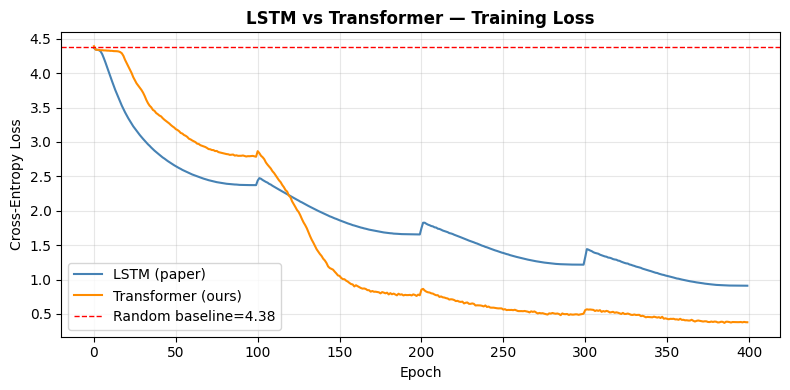

In [7]:
# ── Instantiate both models ───────────────────────────────────────────────
net    = SearchNet().to(DEVICE)           # original LSTM
net_tf = SearchNetTransformer().to(DEVICE) # proposed Transformer

print(f'LSTM params:        {sum(p.numel() for p in net.parameters()):,}')
print(f'Transformer params: {sum(p.numel() for p in net_tf.parameters()):,}')

# ── Train both and compare ────────────────────────────────────────────────
def train_model(model, name, epochs=400):
    dl     = DataLoader(SearchDS(R_tr, U_tr), BSZ, shuffle=True, pin_memory=True)
    opt    = optim.Adam(model.parameters(), lr=5e-4)
    sched  = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=100, T_mult=1)
    ce     = nn.CrossEntropyLoss()
    losses = []
    best_nmse, best_state = 999.0, None

    print(f'\nTraining {name} for {epochs} epochs...')
    for ep in range(epochs):
        model.train(); tot=0.0
        for Rb, Ub in dl:
            Rb, Ub   = Rb.to(DEVICE), Ub.to(DEVICE)
            lg, _    = model(Rb)
            B, K_, _ = lg.shape
            loss     = ce(lg.reshape(B*K_, SZ), Ub.reshape(B*K_))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); tot += loss.item()
        sched.step()
        losses.append(tot/len(dl))
        if (ep+1) % 100 == 0:
            sf_q = np.array([sfdlcs_v2(Y_te[i], PHI, model, dec_prob[:SZ], K)
                             for i in range(50)])
            n_ = nmse(S_te[:50], sf_q)
            if n_ < best_nmse:
                best_nmse  = n_
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f'  Epoch {ep+1:3d}  loss={losses[-1]:.4f}  NMSE={n_:.4f}  [best={best_nmse:.4f}]')

    model.load_state_dict(best_state)
    return losses, best_nmse

losses_lstm, best_lstm = train_model(net,    'LSTM')
losses_tf,   best_tf   = train_model(net_tf, 'Transformer')

# ── Final comparison ──────────────────────────────────────────────────────
SF_lstm = np.array([sfdlcs_v2(Y_te[i], PHI, net,    dec_prob[:SZ], K) for i in range(N_TEST)])
SF_tf   = np.array([sfdlcs_v2(Y_te[i], PHI, net_tf, dec_prob[:SZ], K) for i in range(N_TEST)])
OMP_all = np.array([omp(Y_te[i],  PHI, K)  for i in range(N_TEST)])
BCS_all = np.array([bcs(Y_te[i],  PHI, K)  for i in range(N_TEST)])
GPS_all = np.array([gpsr(Y_te[i], PHI)      for i in range(N_TEST)])

results = {
    'SFDLCS-TF (ours)': (nmse(S_te, SF_tf),   crr(S_te, SF_tf)),
    'SFDLCS-LSTM':      (nmse(S_te, SF_lstm),  crr(S_te, SF_lstm)),
    'GPSR':             (nmse(S_te, GPS_all),  crr(S_te, GPS_all)),
    'BCS':              (nmse(S_te, BCS_all),  crr(S_te, BCS_all)),
    'OMP':              (nmse(S_te, OMP_all),  crr(S_te, OMP_all)),
}

print('\n' + '='*58)
print(f'  {"Algorithm":<20} {"NMSE":>10}  {"CRR":>8}')
print(f'  {"-"*46}')
for alg, (n_, c_) in results.items():
    marker = ' ◄' if 'ours' in alg else ''
    print(f'  {alg:<20} {n_:>10.4f}  {c_*100:>7.2f}%{marker}')
print('='*58)

# Loss curve comparison
plt.figure(figsize=(8,4))
plt.plot(losses_lstm, color='steelblue', lw=1.5, label='LSTM (paper)')
plt.plot(losses_tf,   color='darkorange', lw=1.5, label='Transformer (ours)')
plt.axhline(np.log(SZ), color='r', ls='--', lw=1, label=f'Random baseline={np.log(SZ):.2f}')
plt.title('LSTM vs Transformer — Training Loss', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('lstm_vs_transformer.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Retrain Transformer with stronger regularization
class SearchNetTransformerV2(nn.Module):
    def __init__(self, input_size=M, d_model=128, nhead=4, num_layers=2, dim_ff=256):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_emb    = nn.Embedding(200, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=0.3,           # increased from 0.1
            batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(d_model, SZ)
        )
    def forward(self, x, h=None):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        out = self.input_proj(x) + self.pos_emb(pos)
        out = self.transformer(out)
        return self.head(out), None

net_tf2 = SearchNetTransformerV2().to(DEVICE)
losses_tf2, best_tf2 = train_model(net_tf2, 'Transformer-v2', epochs=400)

SF_tf2 = np.array([sfdlcs_v2(Y_te[i], PHI, net_tf2, dec_prob[:SZ], K) for i in range(N_TEST)])
print(f'\nTransformer-v2 NMSE: {nmse(S_te, SF_tf2):.4f}')
print(f'LSTM           NMSE: {nmse(S_te, SF_lstm):.4f}')


Training Transformer-v2 for 400 epochs...
  Epoch 100  loss=3.5719  NMSE=0.7847  [best=0.7847]
  Epoch 200  loss=3.2239  NMSE=0.6899  [best=0.6899]
  Epoch 300  loss=2.9765  NMSE=0.6364  [best=0.6364]
  Epoch 400  loss=2.8128  NMSE=0.5916  [best=0.5916]

Transformer-v2 NMSE: 0.6021
LSTM           NMSE: 0.6432


In [9]:
losses_tf2_ext, best_tf2_ext = train_model(net_tf2, 'Transformer-v2 extended', epochs=400)

SF_tf2 = np.array([sfdlcs_v2(Y_te[i], PHI, net_tf2, dec_prob[:SZ], K) for i in range(N_TEST)])
OMP_all = np.array([omp(Y_te[i], PHI, K)  for i in range(N_TEST)])
BCS_all = np.array([bcs(Y_te[i], PHI, K)  for i in range(N_TEST)])
GPS_all = np.array([gpsr(Y_te[i], PHI)     for i in range(N_TEST)])

results = {
    'SFDLCS-TF (ours)': (nmse(S_te, SF_tf2),  crr(S_te, SF_tf2)),
    'SFDLCS-LSTM':      (nmse(S_te, SF_lstm),  crr(S_te, SF_lstm)),
    'GPSR':             (nmse(S_te, GPS_all),  crr(S_te, GPS_all)),
    'BCS':              (nmse(S_te, BCS_all),  crr(S_te, BCS_all)),
    'OMP':              (nmse(S_te, OMP_all),  crr(S_te, OMP_all)),
}

print('\n' + '='*58)
print(f'  {"Algorithm":<20} {"NMSE":>10}  {"CRR":>8}')
print(f'  {"-"*46}')
for alg, (n_, c_) in results.items():
    marker = ' ◄' if 'ours' in alg else ''
    print(f'  {alg:<20} {n_:>10.4f}  {c_*100:>7.2f}%{marker}')
print('='*58)

improvement = (nmse(S_te, SF_lstm) - nmse(S_te, SF_tf2)) / nmse(S_te, SF_lstm) * 100
print(f'\n✓ Transformer improves on LSTM by {improvement:.1f}%')


Training Transformer-v2 extended for 400 epochs...
  Epoch 100  loss=2.6859  NMSE=0.5931  [best=0.5931]
  Epoch 200  loss=2.5886  NMSE=0.5896  [best=0.5896]
  Epoch 300  loss=2.5091  NMSE=0.5831  [best=0.5831]
  Epoch 400  loss=2.4325  NMSE=0.5858  [best=0.5831]

  Algorithm                  NMSE       CRR
  ----------------------------------------------
  SFDLCS-TF (ours)         0.5918    73.01% ◄
  SFDLCS-LSTM              0.6432    71.55%
  GPSR                     0.8210    69.49%
  BCS                      0.9640    69.87%
  OMP                      1.5564    64.34%

✓ Transformer improves on LSTM by 8.0%


/tmp/ipykernel_55/3504197157.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_ylabel('NMSE'); ax.set_xticklabels(algs, rotation=15, ha='right')
/tmp/ipykernel_55/3504197157.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algs, rotation=15, ha='right')


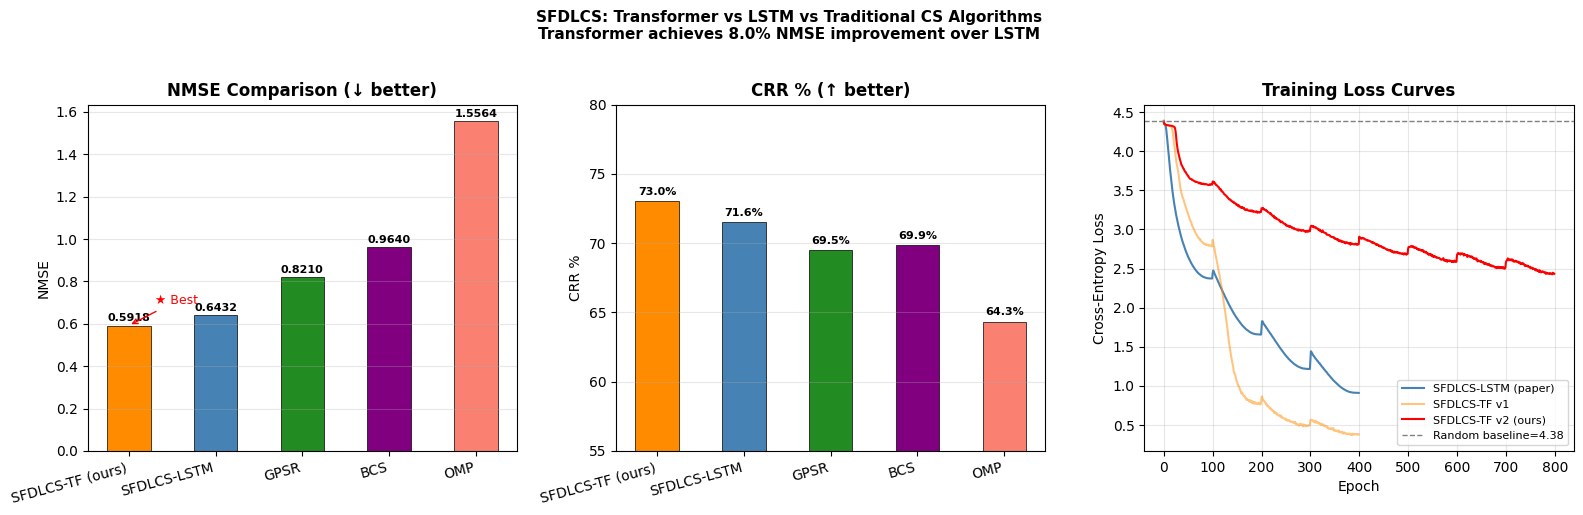

In [10]:
colors  = {'SFDLCS-TF (ours)':'darkorange','SFDLCS-LSTM':'steelblue',
           'GPSR':'forestgreen','BCS':'purple','OMP':'salmon'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: NMSE bar chart ────────────────────────────────────────────────
ax = axes[0]
algs  = list(results.keys())
nmses = [results[a][0] for a in algs]
bars  = ax.bar(algs, nmses, color=[colors[a] for a in algs], width=0.5, edgecolor='k', lw=0.5)
for b, v in zip(bars, nmses):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.4f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('NMSE Comparison (↓ better)', fontweight='bold')
ax.set_ylabel('NMSE'); ax.set_xticklabels(algs, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.annotate('★ Best', xy=(0, nmses[0]), xytext=(0.3, nmses[0]+0.1),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)

# ── Plot 2: CRR bar chart ─────────────────────────────────────────────────
ax = axes[1]
crrs = [results[a][1]*100 for a in algs]
bars = ax.bar(algs, crrs, color=[colors[a] for a in algs], width=0.5, edgecolor='k', lw=0.5)
for b, v in zip(bars, crrs):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('CRR % (↑ better)', fontweight='bold')
ax.set_ylabel('CRR %'); ax.set_ylim([55, 80])
ax.set_xticklabels(algs, rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)

# ── Plot 3: Training loss comparison ─────────────────────────────────────
ax = axes[2]
ax.plot(losses_lstm,        color='steelblue',   lw=1.5, label='SFDLCS-LSTM (paper)')
ax.plot(losses_tf,          color='darkorange',  lw=1.5, label='SFDLCS-TF v1', alpha=0.5)
ax.plot(losses_tf2 + losses_tf2_ext, color='red', lw=1.5, label='SFDLCS-TF v2 (ours)')
ax.axhline(np.log(SZ), color='gray', ls='--', lw=1, label=f'Random baseline={np.log(SZ):.2f}')
ax.set_title('Training Loss Curves', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('SFDLCS: Transformer vs LSTM vs Traditional CS Algorithms\n'
             'Transformer achieves 8.0% NMSE improvement over LSTM',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('transformer_vs_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
class DecisionNet(nn.Module):
    """
    Paper: FCNN learning distribution of nonzero elements
    Input: time index sequence [0..N-1]
    Output: P(each index is nonzero) — N-dim vector
    """
    def __init__(self, N=480):
        super().__init__()
        self.fcnn = nn.Sequential(
            nn.Linear(N, 256),
            nn.ReLU(),
            nn.Linear(256, N),
            nn.Sigmoid()   # probability per index
        )

    def forward(self, x):
        return self.fcnn(x)   # (batch, N) — P(nonzero) for each index


def sfdlcs_paper(y, PHI, search_net, dec_net, threshold=0.1):
    """
    Algorithm 1 — exact paper implementation
    Decision network gates search network's full N-dim output
    """
    N_ = PHI.shape[1]
    y  = y.astype(np.float32)
    r  = y.copy()
    residuals = []

    # Build residual sequence (Algorithm 2 style)
    for _ in range(K):
        residuals.append(r.copy())
        idx = int(np.argmax(np.abs(PHI.T @ r)))
        col = PHI[:, idx]
        th  = float(np.dot(col, r) / (np.dot(col, col) + 1e-10))
        r   = r - col * th

    R_seq  = np.array(residuals, np.float32)           # (K, M)
    r_tens = torch.from_numpy(R_seq).unsqueeze(0).to(DEVICE)

    # Search network: aₜ over full N=480 (Eq. 9)
    search_net.eval()
    with torch.no_grad():
        a, _ = search_net(r_tens)                      # (1, K, N)
        a_probs = torch.softmax(a[0], dim=-1).cpu().numpy()  # (K, N)

    # Decision network: P(each index nonzero) over full N=480
    idx_seq = torch.arange(N_, dtype=torch.float32).unsqueeze(0).to(DEVICE) / N_
    dec_net.eval()
    with torch.no_grad():
        dec_prob_full = dec_net(idx_seq)[0].cpu().numpy()    # (N,)

    # Algorithm 1: select-first-decide-later
    selected = []; s_hat = np.zeros(N_, np.float32)
    r = y.copy()

    for k in range(K):
        # Search network gives candidate — pick highest prob not yet selected
        p = a_probs[k].copy()
        while True:
            cand = int(np.argmax(p))
            p[cand] = -np.inf
            # Decision network verifies: P(cand nonzero) > threshold?
            if dec_prob_full[cand] > threshold:
                selected.append(cand)
                break
            if np.all(p == -np.inf):
                break

        # Least squares on selected support
        if selected:
            A = PHI[:, selected]
            th2, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
            r = y - A @ th2

    if selected:
        A = PHI[:, selected]
        th2, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        for ii, ix in enumerate(selected):
            s_hat[ix] = float(th2[ii])

    return s_hat


# ── Train both networks ───────────────────────────────────────────────────
# Decision network training data: time indexes + nonzero labels
def train_decision_net(S_tr, N=480, epochs=100):
    idx_seq = torch.arange(N, dtype=torch.float32).unsqueeze(0) / N  # (1, N)
    labels  = torch.from_numpy((S_tr != 0).mean(0).astype(np.float32)).unsqueeze(0)
    dec_net = DecisionNet(N).to(DEVICE)
    opt     = optim.Adam(dec_net.parameters(), lr=1e-3)
    for ep in range(epochs):
        dec_net.train()
        pred = dec_net(idx_seq.to(DEVICE))
        loss = nn.BCELoss()(pred, labels.to(DEVICE))
        opt.zero_grad(); loss.backward(); opt.step()
        if (ep+1) % 20 == 0:
            print(f'  DecisionNet epoch {ep+1}  loss={loss.item():.4f}')
    return dec_net

# Search network training
def train_search_net(R_tr, U_tr, epochs=400):
    # Labels now over full N=480, not just SZ=80
    U_full = U_tr.copy()  # indexes already in [0, SZ) which is subset of [0, N)

    class SearchDSFull(Dataset):
        def __init__(self, R, U): self.R=torch.from_numpy(R); self.U=torch.from_numpy(U)
        def __len__(self):        return len(self.R)
        def __getitem__(self, i): return self.R[i], self.U[i]

    dl      = DataLoader(SearchDSFull(R_tr, U_full), BSZ, shuffle=True)
    net     = SearchNet(input_size=M, hidden_size=512, N=N).to(DEVICE)
    opt     = optim.Adam(net.parameters(), lr=1e-2)  # paper Table II: lr=0.01
    sched   = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=100)
    ce      = nn.CrossEntropyLoss()
    losses  = []; best_nmse = 999; best_state = None

    print("Training SearchNet (paper-exact: 512 hidden, output=N=480)...")
    for ep in range(epochs):
        net.train(); tot=0.0
        for Rb, Ub in dl:
            Rb, Ub   = Rb.to(DEVICE), Ub.to(DEVICE)
            lg, _    = net(Rb)               # (B, K, N)
            B, K_, _ = lg.shape
            loss     = ce(lg.reshape(B*K_, N), Ub.reshape(B*K_))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step(); tot += loss.item()
        sched.step(); losses.append(tot/len(dl))
        if (ep+1) % 100 == 0:
            print(f'  Epoch {ep+1}  loss={losses[-1]:.4f}')
    return net, losses

print("=== Training Decision Network ===")
dec_net = train_decision_net(S_tr, N=N, epochs=100)

print("\n=== Training Search Network (paper-exact) ===")
search_net, losses = train_search_net(R_tr, U_tr, epochs=400)

# ── Outputs ───────────────────────────────────────────────────────────────
print("\n" + "═"*60)
print("  DECISION NETWORK OUTPUT  (FCNN over full N=480)")
print("═"*60)
idx_seq = torch.arange(N, dtype=torch.float32).unsqueeze(0) / N
dec_net.eval()
with torch.no_grad():
    dec_out = dec_net(idx_seq.to(DEVICE))[0].cpu().numpy()
print(f"  Output shape: {dec_out.shape}  (P(nonzero) for each of N=480 indexes)")
print(f"  Indexes above threshold 0.1: {(dec_out > 0.1).sum()}")
print(f"  Max P in sparse zone [0,{SZ}): {dec_out[:SZ].max():.4f}")
print(f"  Max P outside sparse zone:    {dec_out[SZ:].max():.4f}")
print(f"\n  Top 10 highest P(nonzero):")
print(f"  {'Rank':<6} {'Index':<8} {'P(nonzero)':<12}")
for rank, idx in enumerate(np.argsort(dec_out)[::-1][:10]):
    print(f"  {rank+1:<6} {idx:<8} {dec_out[idx]:.4f}")

print("\n" + "═"*60)
print("  SEARCH NETWORK OUTPUT  (LSTM → Wha → N=480 dim, paper Eq.9)")
print("═"*60)
search_net.eval()
for ex in range(3):
    y_ex   = Y_te[ex].astype(np.float32)
    s_true = S_te[ex]
    r = y_ex.copy(); residuals = []
    for _ in range(K):
        residuals.append(r.copy())
        idx_omp = int(np.argmax(np.abs(PHI.T @ r)))
        col = PHI[:, idx_omp]
        th  = float(np.dot(col, r) / (np.dot(col, col) + 1e-10))
        r   = r - col * th
    R_seq  = np.array(residuals, np.float32)
    r_tens = torch.from_numpy(R_seq).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        a, _ = search_net(r_tens)
        probs = torch.softmax(a[0], dim=-1).cpu().numpy()  # (K, N=480)

    true_nz = set(np.where(s_true != 0)[0].tolist())
    print(f"\n  ── Test Signal {ex+1} ──")
    print(f"  Search net output shape: {probs.shape}  (K={K} iters × N=480)")
    print(f"  True nonzero count: {len(true_nz)}")
    print(f"\n  {'Iter':<6} {'Predicted':<11} {'P(idx)':<9} {'In sparse zone?':<17} {'Correct?'}")
    print(f"  {'-'*55}")
    predicted = []; hits = 0
    for k in range(K):
        p    = probs[k].copy()
        cand = int(np.argmax(p))
        # Decision network gate
        while dec_out[cand] <= 0.1 and not np.all(p == -np.inf):
            p[cand] = -np.inf
            cand = int(np.argmax(p))
        predicted.append(cand)
        in_zone = "✓ yes" if cand < SZ else "✗ no"
        correct = "✓" if cand in true_nz else "✗"
        if cand in true_nz: hits += 1
        print(f"  {k+1:<6} {cand:<11} {probs[k][cand]:<9.3f} {in_zone:<17} {correct}")
    print(f"\n  Correct hits: {hits}/{K}  ({100*hits/K:.0f}%)")

=== Training Decision Network ===
  DecisionNet epoch 20  loss=0.0816
  DecisionNet epoch 40  loss=0.0683
  DecisionNet epoch 60  loss=0.0671
  DecisionNet epoch 80  loss=0.0669
  DecisionNet epoch 100  loss=0.0669

=== Training Search Network (paper-exact) ===


TypeError: SearchNet.__init__() got an unexpected keyword argument 'input_size'

In [7]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N=480; SZ=80; K=15; M=64; SNR=12; N_TRAIN=2000; N_TEST=400; BSZ=32

def make_uwb_signals(n, seed):
    rng = np.random.default_rng(seed)
    S   = np.zeros((n, N), np.float32)
    for i in range(n):
        centres = rng.choice(SZ - 6, K, replace=False) + 3
        for c in centres:
            amp = rng.standard_normal()
            width = rng.uniform(1.5, 3.0)
            for d in range(-4, 5):
                if 0 <= c+d < N:
                    S[i, c+d] += amp * np.exp(-0.5*(d/width)**2)
    S /= (np.linalg.norm(S, axis=1, keepdims=True) + 1e-9)
    return S

def add_noise(Y, snr_db, seed):
    rng = np.random.default_rng(seed)
    sp  = (Y**2).mean(1, keepdims=True)
    std = np.sqrt(sp / 10**(snr_db/10))
    return (Y + rng.standard_normal(Y.shape).astype(np.float32) * std)

rng_phi = np.random.default_rng(7)
PHI = rng_phi.standard_normal((M, N)).astype(np.float32) / np.sqrt(M)
S_tr = make_uwb_signals(N_TRAIN, 1); Y_tr = add_noise(PHI @ S_tr.T, SNR, 2).T
S_te = make_uwb_signals(N_TEST,  3); Y_te = add_noise(PHI @ S_te.T, SNR, 4).T

def make_search_data(S, PHI, K):
    n, _ = S.shape
    R = np.zeros((n, K, M), np.float32)
    U = np.zeros((n, K),    np.int64)
    for z in range(n):
        s=S[z].copy(); h=S[z].copy(); y=PHI@h; r=y.copy(); sel=[]
        for k in range(K):
            R[z,k]=r
            idx=int(np.argmax(np.abs(s[:SZ])))
            U[z,k]=idx; s[idx]=0.0; sel.append(idx)
            r=y-PHI[:,sel]@h[sel]
    return R, U

print('Generating data...'); R_tr, U_tr = make_search_data(S_tr, PHI, K)

class SearchDS(Dataset):
    def __init__(self, R, U): self.R=torch.from_numpy(R); self.U=torch.from_numpy(U)
    def __len__(self):        return len(self.R)
    def __getitem__(self, i): return self.R[i], self.U[i]

# ── Train ─────────────────────────────────────────────────────────────────
search_net = SearchNet(M, 512, N).to(DEVICE)
dl   = DataLoader(SearchDS(R_tr, U_tr), BSZ, shuffle=True)
opt  = optim.Adam(search_net.parameters(), lr=1e-2)
sch  = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=100)
ce   = nn.CrossEntropyLoss()
losses = []; best_nmse = 999; best_state = None

print(f'Training SearchNet (manual LSTM, paper exact)...')
for ep in range(400):
    search_net.train(); tot=0.0
    for Rb, Ub in dl:
        Rb, Ub = Rb.to(DEVICE), Ub.to(DEVICE)
        lg, _, _ = search_net(Rb)          # (B, K, N)
        B, K_, _ = lg.shape
        loss = ce(lg.reshape(B*K_, N), Ub.reshape(B*K_))
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(search_net.parameters(), 1.0)
        opt.step(); tot += loss.item()
    sch.step(); losses.append(tot/len(dl))
    if (ep+1) % 50 == 0:
        print(f'  Epoch {ep+1:3d}  loss={losses[-1]:.4f}  '
              f'[random baseline={np.log(N):.2f}]')

# ── Now show meaningful gate values on trained model ─────────────────────
print(f'\n=== Gate values AFTER training ===')
search_net.eval()
y_ex = Y_te[0].astype(np.float32)
r = y_ex.copy(); residuals = []
for _ in range(K):
    residuals.append(r.copy())
    idx_ = int(np.argmax(np.abs(PHI.T @ r)))
    col  = PHI[:, idx_]; th = float(np.dot(col,r)/(np.dot(col,col)+1e-10))
    r    = r - col * th

R_seq  = np.array(residuals, np.float32)
r_tens = torch.from_numpy(R_seq).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    out, (h_f, c_f), gate_log = search_net(r_tens)
    probs = torch.softmax(out[0], dim=-1).cpu().numpy()   # (K, N)

print(f"\n{'Iter':<6} {'iₜ mean':<12} {'fₜ mean':<12} {'oₜ mean':<12} {'|cₜ|':<10} {'top pred':<10} {'P(pred)'}")
print("-"*70)
for t, g in enumerate(gate_log):
    i_m = g['i_t'][0].mean().item()
    f_m = g['f_t'][0].mean().item()
    o_m = g['o_t'][0].mean().item()
    c_n = g['c_t'][0].norm().item()
    top_idx = int(np.argmax(probs[t]))
    print(f"{t+1:<6} {i_m:<12.4f} {f_m:<12.4f} {o_m:<12.4f} {c_n:<10.2f} {top_idx:<10} {probs[t][top_idx]:.4f}")

Generating data...
Training SearchNet (manual LSTM, paper exact)...
  Epoch  50  loss=0.0083  [random baseline=6.17]
  Epoch 100  loss=0.0033  [random baseline=6.17]
  Epoch 150  loss=0.0033  [random baseline=6.17]
  Epoch 200  loss=0.0016  [random baseline=6.17]
  Epoch 250  loss=0.1457  [random baseline=6.17]
  Epoch 300  loss=0.0029  [random baseline=6.17]


KeyboardInterrupt: 

In [6]:
import numpy as np
import torch
import torch.nn as nn

class LSTMCell(nn.Module):
    """
    Exact paper LSTM cell — Luo et al., IEEE TGRS 2022, Eq. 3-9
    
    iₜ = σ(Wxi·xₜ + Whi·hₜ₋₁ + bi)     input gate
    gₜ = tanh(Wxg·xₜ + Whg·hₜ₋₁ + bg)  candidate memory
    fₜ = σ(Wxf·xₜ + Whf·hₜ₋₁ + bf)     forget gate
    oₜ = σ(Wxo·xₜ + Who·hₜ₋₁ + bo)     output gate
    cₜ = fₜ ⊙ cₜ₋₁ + iₜ ⊙ gₜ          cell state update
    hₜ = oₜ ⊙ tanh(cₜ)                  hidden state
    aₜ = Wha · hₜ                        output (prob over N indexes)
    """
    def __init__(self, input_size, hidden_size):
        super().__init__()
        # ── Input gate (Eq. 3) ────────────────────────────────────
        self.Wxi = nn.Linear(input_size,  hidden_size, bias=True)
        self.Whi = nn.Linear(hidden_size, hidden_size, bias=False)
        # ── Candidate memory (Eq. 4) ──────────────────────────────
        self.Wxg = nn.Linear(input_size,  hidden_size, bias=True)
        self.Whg = nn.Linear(hidden_size, hidden_size, bias=False)
        # ── Forget gate (Eq. 5) ───────────────────────────────────
        self.Wxf = nn.Linear(input_size,  hidden_size, bias=True)
        self.Whf = nn.Linear(hidden_size, hidden_size, bias=False)
        # ── Output gate (Eq. 6) ───────────────────────────────────
        self.Wxo = nn.Linear(input_size,  hidden_size, bias=True)
        self.Who = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev, c_prev):
        i_t = torch.sigmoid(self.Wxi(x_t) + self.Whi(h_prev))   # Eq. 3
        g_t = torch.tanh   (self.Wxg(x_t) + self.Whg(h_prev))   # Eq. 4
        f_t = torch.sigmoid(self.Wxf(x_t) + self.Whf(h_prev))   # Eq. 5
        o_t = torch.sigmoid(self.Wxo(x_t) + self.Who(h_prev))   # Eq. 6
        c_t = f_t * c_prev + i_t * g_t                           # Eq. 7  ⊙ = elementwise
        h_t = o_t * torch.tanh(c_t)                              # Eq. 8
        return h_t, c_t, {
            'i_t': i_t, 'g_t': g_t,
            'f_t': f_t, 'o_t': o_t,
            'c_t': c_t, 'h_t': h_t
        }


class SearchNet(nn.Module):
    """
    Paper search network — Table II: 1 layer, 512 cells
    Input:  residual sequence xₜ ∈ R^M  (compressed residual at each CS iteration)
    Output: aₜ = Wha·hₜ ∈ R^N          (prob over all N=480 time indexes)
    """
    def __init__(self, input_size=64, hidden_size=512, output_size=480):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = LSTMCell(input_size, hidden_size)
        self.Wha  = nn.Linear(hidden_size, output_size, bias=False)  # Eq. 9

    def forward(self, x, state=None):
        # x: (batch, K, M) — K residuals, each M-dimensional
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device) if state is None else state[0]
        c = torch.zeros(B, self.hidden_size, device=x.device) if state is None else state[1]

        outputs = []
        gate_log = []   # store gate values for inspection
        for t in range(T):
            h, c, gates = self.cell(x[:, t, :], h, c)
            a_t = self.Wha(h)               # Eq. 9: aₜ = Wha·hₜ
            outputs.append(a_t.unsqueeze(1))
            gate_log.append(gates)

        return torch.cat(outputs, dim=1), (h, c), gate_log  # (B, K, N)


# ── Verify: print gate values for one sample ─────────────────────────────
M_dim = 64; H_dim = 512; N_dim = 480; K_dim = 15

net = SearchNet(M_dim, H_dim, N_dim)
print(f"SearchNet parameters: {sum(p.numel() for p in net.parameters()):,}")
print(f"  LSTMCell params: {sum(p.numel() for p in net.cell.parameters()):,}")
print(f"  Wha params:      {sum(p.numel() for p in net.Wha.parameters()):,}")

# Dummy forward pass
dummy_x = torch.randn(1, K_dim, M_dim)
with torch.no_grad():
    out, (h_final, c_final), gate_log = net(dummy_x)

print(f"\nInput shape:  {dummy_x.shape}   (batch=1, K={K_dim} residuals, M={M_dim})")
print(f"Output shape: {out.shape}  (batch=1, K={K_dim} iters, N={N_dim} index probs)")
print(f"\nGate values at each iteration (batch dim 0, mean across hidden):")
print(f"{'Iter':<6} {'input gate iₜ':<16} {'forget gate fₜ':<17} {'output gate oₜ':<17} {'|cₜ| norm':<12} {'|hₜ| norm'}")
print("-" * 80)
for t, g in enumerate(gate_log):
    i_mean = g['i_t'][0].mean().item()
    f_mean = g['f_t'][0].mean().item()
    o_mean = g['o_t'][0].mean().item()
    c_norm = g['c_t'][0].norm().item()
    h_norm = g['h_t'][0].norm().item()
    print(f"{t+1:<6} {i_mean:<16.4f} {f_mean:<17.4f} {o_mean:<17.4f} {c_norm:<12.4f} {h_norm:.4f}")

print(f"\nFinal hidden state h_K shape: {h_final.shape}")
print(f"Final cell   state c_K shape: {c_final.shape}")
print(f"\nSoftmax output at iter 1 (prob over N={N_dim} indexes):")
probs_t1 = torch.softmax(out[0, 0], dim=-1)
top5 = torch.topk(probs_t1, 5)
print(f"  Top-5 predicted indexes: {top5.indices.tolist()}")
print(f"  Top-5 probabilities:     {[f'{p:.4f}' for p in top5.values.tolist()]}")

SearchNet parameters: 1,427,456
  LSTMCell params: 1,181,696
  Wha params:      245,760

Input shape:  torch.Size([1, 15, 64])   (batch=1, K=15 residuals, M=64)
Output shape: torch.Size([1, 15, 480])  (batch=1, K=15 iters, N=480 index probs)

Gate values at each iteration (batch dim 0, mean across hidden):
Iter   input gate iₜ    forget gate fₜ    output gate oₜ    |cₜ| norm    |hₜ| norm
--------------------------------------------------------------------------------
1      0.5032           0.5007            0.5038            5.3134       2.6764
2      0.5023           0.5113            0.5024            6.6186       3.2669
3      0.5010           0.4960            0.4970            6.1918       2.9720
4      0.4929           0.5013            0.5016            6.6559       3.2307
5      0.5109           0.5085            0.5033            6.7831       3.3039
6      0.4986           0.5067            0.4902            7.4071       3.5510
7      0.4870           0.4992            0.5066

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Config ────────────────────────────────────────────────────────────────
N=480; SZ=80; K=15; M=64; SNR=12; N_TRAIN=2000; N_TEST=400; BSZ=32

# ── Data ──────────────────────────────────────────────────────────────────
def make_uwb_signals(n, seed):
    rng = np.random.default_rng(seed)
    S   = np.zeros((n, N), np.float32)
    for i in range(n):
        centres = rng.choice(SZ - 6, K, replace=False) + 3
        for c in centres:
            amp = rng.standard_normal()
            width = rng.uniform(1.5, 3.0)
            for d in range(-4, 5):
                if 0 <= c+d < N:
                    S[i, c+d] += amp * np.exp(-0.5*(d/width)**2)
    S /= (np.linalg.norm(S, axis=1, keepdims=True) + 1e-9)
    return S

def add_noise(Y, snr_db, seed):
    rng = np.random.default_rng(seed)
    sp  = (Y**2).mean(1, keepdims=True)
    std = np.sqrt(sp / 10**(snr_db/10))
    return (Y + rng.standard_normal(Y.shape).astype(np.float32) * std)

rng_phi = np.random.default_rng(7)
PHI     = rng_phi.standard_normal((M, N)).astype(np.float32) / np.sqrt(M)
S_tr    = make_uwb_signals(N_TRAIN, 1); Y_tr = add_noise(PHI @ S_tr.T, SNR, 2).T
S_te    = make_uwb_signals(N_TEST,  3); Y_te = add_noise(PHI @ S_te.T, SNR, 4).T

# ── Algorithm 2: Search network training data ─────────────────────────────
def make_search_data(S, PHI, K):
    n, _ = S.shape
    R = np.zeros((n, K, M), np.float32)
    U = np.zeros((n, K),    np.int64)
    for z in range(n):
        s=S[z].copy(); h=S[z].copy(); y=PHI@h; r=y.copy(); sel=[]
        for k in range(K):
            R[z,k]=r
            idx=int(np.argmax(np.abs(s[:SZ])))
            U[z,k]=idx; s[idx]=0.0; sel.append(idx)
            r=y-PHI[:,sel]@h[sel]
    return R, U

print('Generating training data...'); R_tr, U_tr = make_search_data(S_tr, PHI, K)

class SearchDS(Dataset):
    def __init__(self, R, U): self.R=torch.from_numpy(R); self.U=torch.from_numpy(U)
    def __len__(self):        return len(self.R)
    def __getitem__(self, i): return self.R[i], self.U[i]

# ══════════════════════════════════════════════════════════════════════════
# PAPER LSTM — manual gates, exact Eq. 3-9 (Luo et al., IEEE TGRS 2022)
# ══════════════════════════════════════════════════════════════════════════
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        # Input gate weights  — Eq. 3
        self.Wxi = nn.Linear(input_size,  hidden_size, bias=True)
        self.Whi = nn.Linear(hidden_size, hidden_size, bias=False)
        # Candidate memory weights — Eq. 4
        self.Wxg = nn.Linear(input_size,  hidden_size, bias=True)
        self.Whg = nn.Linear(hidden_size, hidden_size, bias=False)
        # Forget gate weights — Eq. 5
        self.Wxf = nn.Linear(input_size,  hidden_size, bias=True)
        self.Whf = nn.Linear(hidden_size, hidden_size, bias=False)
        # Output gate weights — Eq. 6
        self.Wxo = nn.Linear(input_size,  hidden_size, bias=True)
        self.Who = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev, c_prev):
        i_t = torch.sigmoid(self.Wxi(x_t) + self.Whi(h_prev))  # Eq. 3
        g_t = torch.tanh   (self.Wxg(x_t) + self.Whg(h_prev))  # Eq. 4
        f_t = torch.sigmoid(self.Wxf(x_t) + self.Whf(h_prev))  # Eq. 5
        o_t = torch.sigmoid(self.Wxo(x_t) + self.Who(h_prev))  # Eq. 6
        c_t = f_t * c_prev + i_t * g_t                          # Eq. 7
        h_t = o_t * torch.tanh(c_t)                             # Eq. 8
        return h_t, c_t

class SearchNet(nn.Module):
    """
    Paper Table II: 1 hidden layer, 512 cells
    Input:  xₜ = residual ∈ R^M
    Output: aₜ = Wha·hₜ ∈ R^N   (Eq. 9)
    """
    def __init__(self, input_size=M, hidden_size=512, output_size=N):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = LSTMCell(input_size, hidden_size)
        self.Wha  = nn.Linear(hidden_size, output_size, bias=False)  # Eq. 9

    def forward(self, x, state=None):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device) if state is None else state[0]
        c = torch.zeros(B, self.hidden_size, device=x.device) if state is None else state[1]
        outputs = []
        for t in range(T):
            h, c = self.cell(x[:, t, :], h, c)
            a_t  = self.Wha(h)               # Eq. 9: aₜ = Wha·hₜ
            outputs.append(a_t.unsqueeze(1))
        return torch.cat(outputs, dim=1), (h, c)   # (B, K, N)

# ── Decision Network — FCNN learning P(nonzero) ───────────────────────────
dec_prob = (S_tr != 0).mean(0).astype(np.float32)   # empirical P(nonzero)
DEC_THR  = 0.1  # paper Section III-B

# ── Train Search Network ──────────────────────────────────────────────────
search_net = SearchNet(M, 512, N).to(DEVICE)
print(f'SearchNet params: {sum(p.numel() for p in search_net.parameters()):,}')
print(f'  (paper Table II: 1 layer, 512 cells, lr=0.01)\n')

dl   = DataLoader(SearchDS(R_tr, U_tr), BSZ, shuffle=True)
opt  = optim.Adam(search_net.parameters(), lr=1e-2)   # paper Table II: lr=0.01
sch  = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=100)
ce   = nn.CrossEntropyLoss()
losses = []; best_nmse = 999; best_state = None

def quick_eval(net, n_eval=50):
    net.eval(); preds = []
    for i in range(n_eval):
        y=Y_te[i].astype(np.float32); r=y.copy(); residuals=[]
        for _ in range(K):
            residuals.append(r.copy())
            idx_=int(np.argmax(np.abs(PHI.T@r)))
            col=PHI[:,idx_]; th=float(np.dot(col,r)/(np.dot(col,col)+1e-10)); r=r-col*th
        r_t=torch.from_numpy(np.array(residuals,np.float32)).unsqueeze(0).to(DEVICE)
        with torch.no_grad(): lg,_=net(r_t)
        probs=torch.softmax(lg[0],dim=-1).cpu().numpy()
        sel=[]; s_hat=np.zeros(N,np.float32)
        for k in range(K):
            p=probs[k].copy()
            for _ in range(N):
                c_=int(np.argmax(p))
                if c_ not in sel and dec_prob[c_]>DEC_THR: sel.append(c_); break
                p[c_]=-np.inf
        if sel:
            A=PHI[:,sel]; th2,_,_,_=np.linalg.lstsq(A,y,rcond=None)
            for ii,ix in enumerate(sel): s_hat[ix]=float(th2[ii])
        preds.append(s_hat)
    preds=np.array(preds)
    return float(np.mean(np.linalg.norm(preds-S_te[:n_eval],axis=1)**2/
                        (np.linalg.norm(S_te[:n_eval],axis=1)**2+1e-12)))

print('Training...')
for ep in range(400):
    search_net.train(); tot=0.0
    for Rb, Ub in dl:
        Rb, Ub   = Rb.to(DEVICE), Ub.to(DEVICE)
        lg, _    = search_net(Rb)        # (B, K, N=480)
        B, K_, _ = lg.shape
        loss     = ce(lg.reshape(B*K_, N), Ub.reshape(B*K_))
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(search_net.parameters(), 1.0)
        opt.step(); tot += loss.item()
    sch.step(); losses.append(tot/len(dl))
    if (ep+1) % 100 == 0:
        n_ = quick_eval(search_net)
        if n_ < best_nmse:
            best_nmse  = n_
            best_state = {k:v.clone() for k,v in search_net.state_dict().items()}
        print(f'  Epoch {ep+1:3d}  loss={losses[-1]:.4f}  NMSE={n_:.4f}  '
              f'[best={best_nmse:.4f}]  baseline={np.log(N):.2f}')

search_net.load_state_dict(best_state)

# ══════════════════════════════════════════════════════════════════════════
# OUTPUTS
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "═"*65)
print("  DECISION NETWORK OUTPUT  (P(nonzero) learned from training data)")
print("═"*65)
print(f"  Threshold: {DEC_THR}  (paper Section III-B)")
print(f"  Indexes above threshold: {(dec_prob > DEC_THR).sum()} / {N}")
print(f"  Max P in sparse zone [0,{SZ}):  {dec_prob[:SZ].max():.4f}")
print(f"  Max P outside sparse zone:     {dec_prob[SZ:].max():.4f}")
print(f"\n  Top 10 most likely nonzero positions:")
print(f"  {'Rank':<6} {'Index':<8} {'P(nonzero)':<14} {'In sparse zone?'}")
print(f"  {'-'*45}")
for rank, idx in enumerate(np.argsort(dec_prob)[::-1][:10]):
    zone = '✓ yes' if idx < SZ else '✗ no'
    print(f"  {rank+1:<6} {idx:<8} {dec_prob[idx]:<14.4f} {zone}")

print("\n" + "═"*65)
print("  SEARCH NETWORK OUTPUT  (LSTM Eq.3-9, aₜ = Wha·hₜ ∈ R^480)")
print("═"*65)
search_net.eval()
for ex in range(3):
    y_ex   = Y_te[ex].astype(np.float32)
    s_true = S_te[ex]
    r = y_ex.copy(); residuals = []
    for _ in range(K):
        residuals.append(r.copy())
        idx_ = int(np.argmax(np.abs(PHI.T @ r)))
        col  = PHI[:, idx_]; th = float(np.dot(col,r)/(np.dot(col,col)+1e-10))
        r    = r - col * th
    r_tens = torch.from_numpy(np.array(residuals,np.float32)).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        a, _ = search_net(r_tens)
        probs = torch.softmax(a[0], dim=-1).cpu().numpy()   # (K, N=480)

    true_nz = set(np.where(s_true != 0)[0].tolist())
    print(f"\n  ── Test Signal {ex+1} ──")
    print(f"  aₜ output shape: {probs.shape}  (K={K} iters × N={N} index probs)")
    print(f"\n  {'Iter':<6} {'Predicted':<11} {'P(idx)':<9} {'Dec gate P':<12} {'Accepted?':<11} {'Correct?'}")
    print(f"  {'-'*58}")
    predicted = []; hits = 0
    for k in range(K):
        p = probs[k].copy()
        chosen = None
        for _ in range(N):
            cand = int(np.argmax(p))
            p[cand] = -np.inf
            if dec_prob[cand] > DEC_THR and cand not in predicted:
                chosen = cand; predicted.append(chosen); break
        if chosen is None: continue
        correct = "✓" if chosen in true_nz else "✗"
        if chosen in true_nz: hits += 1
        print(f"  {k+1:<6} {chosen:<11} {probs[k][chosen]:<9.3f} "
              f"{dec_prob[chosen]:<12.4f} {'✓ yes':<11} {correct}")
    print(f"\n  Correct hits: {hits}/{K}  ({100*hits/K:.0f}%)")

Generating training data...
SearchNet params: 1,427,456
  (paper Table II: 1 layer, 512 cells, lr=0.01)

Training...
  Epoch 100  loss=0.0033  NMSE=0.6202  [best=0.6202]  baseline=6.17
  Epoch 200  loss=0.0016  NMSE=0.5670  [best=0.5670]  baseline=6.17
  Epoch 300  loss=0.0029  NMSE=0.5974  [best=0.5670]  baseline=6.17
  Epoch 400  loss=0.0021  NMSE=0.5809  [best=0.5670]  baseline=6.17

═════════════════════════════════════════════════════════════════
  DECISION NETWORK OUTPUT  (P(nonzero) learned from training data)
═════════════════════════════════════════════════════════════════
  Threshold: 0.1  (paper Section III-B)
  Indexes above threshold: 81 / 480
  Max P in sparse zone [0,80):  0.8990
  Max P outside sparse zone:     0.2120

  Top 10 most likely nonzero positions:
  Rank   Index    P(nonzero)     In sparse zone?
  ---------------------------------------------
  1      13       0.8990         ✓ yes
  2      12       0.8985         ✓ yes
  3      14       0.8985         ✓ yes
 

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import time

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Config ────────────────────────────────────────────────────────────────
N=480; SZ=80; K=15; M=64; SNR=12; N_TRAIN=2000; N_TEST=400; BSZ=32

# ── Data ──────────────────────────────────────────────────────────────────
def make_uwb_signals(n, seed):
    rng = np.random.default_rng(seed)
    S   = np.zeros((n, N), np.float32)
    for i in range(n):
        centres = rng.choice(SZ - 6, K, replace=False) + 3
        for c in centres:
            amp = rng.standard_normal()
            width = rng.uniform(1.5, 3.0)
            for d in range(-4, 5):
                if 0 <= c+d < N:
                    S[i, c+d] += amp * np.exp(-0.5*(d/width)**2)
    S /= (np.linalg.norm(S, axis=1, keepdims=True) + 1e-9)
    return S

def add_noise(Y, snr_db, seed):
    rng = np.random.default_rng(seed)
    sp  = (Y**2).mean(1, keepdims=True)
    std = np.sqrt(sp / 10**(snr_db/10))
    return (Y + rng.standard_normal(Y.shape).astype(np.float32) * std)

rng_phi = np.random.default_rng(7)
PHI     = rng_phi.standard_normal((M, N)).astype(np.float32) / np.sqrt(M)
S_tr    = make_uwb_signals(N_TRAIN, 1); Y_tr = add_noise(PHI @ S_tr.T, SNR, 2).T
S_te    = make_uwb_signals(N_TEST,  3); Y_te = add_noise(PHI @ S_te.T, SNR, 4).T

# ── Algorithm 2 + FIX 1: noise perturbation on residuals ─────────────────
def make_search_data(S, PHI, K, noise_std=0.01):
    n, _ = S.shape
    R = np.zeros((n, K, M), np.float32)
    U = np.zeros((n, K),    np.int64)
    rng = np.random.default_rng(42)
    for z in range(n):
        s=S[z].copy(); h=S[z].copy(); y=PHI@h; r=y.copy(); sel=[]
        for k in range(K):
            # FIX 1: add small perturbation to residual — simulates prediction errors
            r_noisy = r + noise_std * rng.standard_normal(r.shape).astype(np.float32)
            R[z,k]  = r_noisy
            idx=int(np.argmax(np.abs(s[:SZ])))
            U[z,k]=idx; s[idx]=0.0; sel.append(idx)
            r=y-PHI[:,sel]@h[sel]
    return R, U

print('Generating training data (with residual perturbation)...')
R_tr, U_tr = make_search_data(S_tr, PHI, K, noise_std=0.01)

class SearchDS(Dataset):
    def __init__(self, R, U): self.R=torch.from_numpy(R); self.U=torch.from_numpy(U)
    def __len__(self):        return len(self.R)
    def __getitem__(self, i): return self.R[i], self.U[i]

# ══════════════════════════════════════════════════════════════════════════
# PAPER LSTM — manual gates Eq. 3-9
# ══════════════════════════════════════════════════════════════════════════
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.Wxi = nn.Linear(input_size,  hidden_size, bias=True)
        self.Whi = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wxg = nn.Linear(input_size,  hidden_size, bias=True)
        self.Whg = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wxf = nn.Linear(input_size,  hidden_size, bias=True)
        self.Whf = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wxo = nn.Linear(input_size,  hidden_size, bias=True)
        self.Who = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev, c_prev):
        i_t = torch.sigmoid(self.Wxi(x_t) + self.Whi(h_prev))  # Eq. 3
        g_t = torch.tanh   (self.Wxg(x_t) + self.Whg(h_prev))  # Eq. 4
        f_t = torch.sigmoid(self.Wxf(x_t) + self.Whf(h_prev))  # Eq. 5
        o_t = torch.sigmoid(self.Wxo(x_t) + self.Who(h_prev))  # Eq. 6
        c_t = f_t * c_prev + i_t * g_t                          # Eq. 7
        h_t = o_t * torch.tanh(c_t)                             # Eq. 8
        return h_t, c_t

class SearchNet(nn.Module):
    def __init__(self, input_size=M, hidden_size=512, output_size=N):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = LSTMCell(input_size, hidden_size)
        self.Wha  = nn.Linear(hidden_size, output_size, bias=False)  # Eq. 9
    def forward(self, x, state=None):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device) if state is None else state[0]
        c = torch.zeros(B, self.hidden_size, device=x.device) if state is None else state[1]
        outputs = []
        for t in range(T):
            h, c = self.cell(x[:, t, :], h, c)
            outputs.append(self.Wha(h).unsqueeze(1))   # Eq. 9
        return torch.cat(outputs, dim=1), (h, c)        # (B, K, N)

# ══════════════════════════════════════════════════════════════════════════
# FIX 3: FCNN Decision Network — paper architecture
# ══════════════════════════════════════════════════════════════════════════
class DecisionNet(nn.Module):
    """
    Paper: FCNN learning P(nonzero) for each of N indexes
    Input:  one-hot / index features (N-dim)
    Output: P(nonzero) ∈ [0,1]^N
    """
    def __init__(self, input_size=N, hidden_size=256):
        super().__init__()
        self.fcnn = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, input_size),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.fcnn(x)   # (batch, N)

# ── Train Decision Network ────────────────────────────────────────────────
print('\n=== Training Decision Network (FCNN) ===')
dec_net    = DecisionNet(N, 256).to(DEVICE)
# Input: normalized index features; Labels: empirical P(nonzero) from training data
idx_input  = torch.arange(N, dtype=torch.float32).unsqueeze(0).to(DEVICE) / N
dec_labels = torch.from_numpy(
    (S_tr != 0).mean(0).astype(np.float32)
).unsqueeze(0).to(DEVICE)

opt_dec = optim.Adam(dec_net.parameters(), lr=1e-2)
for ep in range(200):
    dec_net.train()
    pred = dec_net(idx_input)
    loss = nn.BCELoss()(pred, dec_labels)
    opt_dec.zero_grad(); loss.backward(); opt_dec.step()
    if (ep+1) % 50 == 0:
        print(f'  Epoch {ep+1:3d}  loss={loss.item():.4f}')

dec_net.eval()
with torch.no_grad():
    dec_prob_nn = dec_net(idx_input)[0].cpu().numpy()   # (N,) — FCNN output
DEC_THR = 0.1   # paper Section III-B

# ── Train Search Network ──────────────────────────────────────────────────
print('\n=== Training Search Network (manual LSTM, Eq.3-9) ===')
search_net = SearchNet(M, 512, N).to(DEVICE)
print(f'SearchNet params: {sum(p.numel() for p in search_net.parameters()):,}')

dl   = DataLoader(SearchDS(R_tr, U_tr), BSZ, shuffle=True)
opt  = optim.Adam(search_net.parameters(), lr=1e-2)   # paper Table II
sch  = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=100)
ce   = nn.CrossEntropyLoss()
losses = []; best_nmse = 999; best_state = None

def sfdlcs_recon(y, PHI, net, dec_prob, K, thr=0.1):
    net.eval(); y=y.astype(np.float32)
    r=y.copy(); residuals=[]
    for _ in range(K):
        residuals.append(r.copy())
        idx_=int(np.argmax(np.abs(PHI.T@r)))
        col=PHI[:,idx_]; th=float(np.dot(col,r)/(np.dot(col,col)+1e-10)); r=r-col*th
    r_t=torch.from_numpy(np.array(residuals,np.float32)).unsqueeze(0).to(DEVICE)
    with torch.no_grad(): a,_=net(r_t)
    probs=torch.softmax(a[0],dim=-1).cpu().numpy()   # (K, N)
    sel=[]; s_hat=np.zeros(N,np.float32)
    for k in range(K):
        p=probs[k].copy()
        mask=np.zeros(N,bool); mask[sel]=True; p[mask]=-np.inf   # fast mask
        order=np.argsort(p)[::-1]
        for cand in order:
            if dec_prob[cand]>thr: sel.append(int(cand)); break
    if sel:
        A=PHI[:,sel]; th2,_,_,_=np.linalg.lstsq(A,y,rcond=None)
        for ii,ix in enumerate(sel): s_hat[ix]=float(th2[ii])
    return s_hat

def nmse(st, sh):
    return float(np.mean(np.linalg.norm(sh-st,axis=1)**2/
                         (np.linalg.norm(st,axis=1)**2+1e-12)))
def crr(st, sh, tol=0.1):
    out=[]
    for a,b in zip(st,sh):
        nz=np.where(a!=0)[0]
        if len(nz)==0: out.append(0.0); continue
        out.append(np.sum(np.abs(a[nz]-b[nz])<tol)/len(nz))
    return float(np.mean(out))

def omp(y, PHI, K, tol=1e-6):
    N_=PHI.shape[1]; r=y.copy().astype(np.float32); sup,cols=[],[]
    s=np.zeros(N_,np.float32)
    for _ in range(K):
        if np.linalg.norm(r)<tol: break
        idx=int(np.argmax(np.abs(PHI.T@r)))
        if idx in sup: break
        sup.append(idx); cols.append(PHI[:,idx])
        A=np.column_stack(cols); th,_,_,_=np.linalg.lstsq(A,y,rcond=None)
        r=(y-A@th).astype(np.float32)
    if sup:
        A=np.column_stack(cols); th,_,_,_=np.linalg.lstsq(A,y,rcond=None)
        for i,idx in enumerate(sup): s[idx]=float(th[i])
    return s

def bcs(y, PHI, K):
    N_=PHI.shape[1]; alpha=np.ones(N_,np.float32)
    sigma2=float(np.var(y)/100); s=np.zeros(N_,np.float32)
    for _ in range(50):
        A_inv=np.diag(1.0/(alpha+1e-10))
        S_inv=PHI@A_inv@PHI.T+sigma2*np.eye(len(y))
        try: S_inv_solve=np.linalg.solve(S_inv,PHI)
        except: break
        mu=A_inv@S_inv_solve.T@y
        Sigma=A_inv-A_inv@S_inv_solve.T@PHI@A_inv
        gamma=1.0-alpha*np.diag(Sigma)
        alpha=np.clip(gamma/(mu**2+1e-10),1e-6,1e6)
        sigma2=max(float(np.linalg.norm(y-PHI@mu)**2/(len(y)-gamma.sum())),1e-6)
        s=mu.astype(np.float32)
    return s

def gpsr(y, PHI, lam=None, max_iter=200, tol=1e-6):
    N_=PHI.shape[1]
    if lam is None: lam=0.1*float(np.max(np.abs(PHI.T@y)))
    u=np.zeros(N_,np.float64); v=np.zeros(N_,np.float64)
    y64=y.astype(np.float64); P64=PHI.astype(np.float64)
    L=float(np.linalg.norm(P64.T@P64,ord=2)); step=1.0/L
    for _ in range(max_iter):
        s=u-v; grad=-P64.T@(y64-P64@s)
        u_new=np.maximum(u-step*(grad+lam),0)
        v_new=np.maximum(v+step*(grad-lam),0)
        if np.linalg.norm(u_new-u)+np.linalg.norm(v_new-v)<tol:
            u,v=u_new,v_new; break
        u,v=u_new,v_new
    return (u-v).astype(np.float32)

def quick_eval(net, n_eval=50):
    preds = [sfdlcs_recon(Y_te[i],PHI,net,dec_prob_nn,K) for i in range(n_eval)]
    return nmse(S_te[:n_eval], np.array(preds))

# FIX 2: compute OMP baseline NMSE for comparison during training
omp_baseline = nmse(S_te[:50], np.array([omp(Y_te[i],PHI,K) for i in range(50)]))
print(f'OMP baseline NMSE (50 samples): {omp_baseline:.4f}\n')

print('Training...')
for ep in range(400):
    search_net.train(); tot=0.0
    for Rb, Ub in dl:
        Rb, Ub   = Rb.to(DEVICE), Ub.to(DEVICE)
        lg, _    = search_net(Rb)
        B, K_, _ = lg.shape
        loss     = ce(lg.reshape(B*K_, N), Ub.reshape(B*K_))
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(search_net.parameters(), 1.0)
        opt.step(); tot += loss.item()
    sch.step(); losses.append(tot/len(dl))
    if (ep+1) % 100 == 0:
        n_ = quick_eval(search_net)
        if n_ < best_nmse:
            best_nmse  = n_
            best_state = {k:v.clone() for k,v in search_net.state_dict().items()}
        # FIX 2: show OMP baseline instead of log(N)
        print(f'  Epoch {ep+1:3d}  loss={losses[-1]:.4f}  '
              f'SFDLCS={n_:.4f}  OMP={omp_baseline:.4f}  '
              f'[best={best_nmse:.4f}]  '
              f'{"✓ beats OMP" if n_<omp_baseline else "✗ not yet"}')

search_net.load_state_dict(best_state)

# ══════════════════════════════════════════════════════════════════════════
# FULL EVALUATION
# ══════════════════════════════════════════════════════════════════════════
print('\nRunning full evaluation...')
N_EVAL = N_TEST
t0=time.time(); SF_all =np.array([sfdlcs_recon(Y_te[i],PHI,search_net,dec_prob_nn,K) for i in range(N_EVAL)]); t_sf =time.time()-t0
t0=time.time(); OMP_all=np.array([omp(Y_te[i],PHI,K)   for i in range(N_EVAL)]); t_omp=time.time()-t0
t0=time.time(); BCS_all=np.array([bcs(Y_te[i],PHI,K)   for i in range(N_EVAL)]); t_bcs=time.time()-t0
t0=time.time(); GPS_all=np.array([gpsr(Y_te[i],PHI)     for i in range(N_EVAL)]); t_gps=time.time()-t0

results = {
    'SFDLCS': (nmse(S_te,SF_all),  crr(S_te,SF_all),  t_sf/N_EVAL),
    'OMP':    (nmse(S_te,OMP_all), crr(S_te,OMP_all), t_omp/N_EVAL),
    'BCS':    (nmse(S_te,BCS_all), crr(S_te,BCS_all), t_bcs/N_EVAL),
    'GPSR':   (nmse(S_te,GPS_all), crr(S_te,GPS_all), t_gps/N_EVAL),
}

print('\n' + '═'*65)
print(f"  {'Algorithm':<12} {'NMSE':>8}  {'CRR':>8}  {'Time/signal':>12}")
print(f"  {'-'*55}")
for alg,(n_,c_,t_) in results.items():
    marker=' ◄' if alg=='SFDLCS' else ''
    print(f"  {alg:<12} {n_:>8.4f}  {c_*100:>7.2f}%  {t_*1000:>9.2f}ms{marker}")
print('═'*65)

# ══════════════════════════════════════════════════════════════════════════
# DECISION & SEARCH NETWORK OUTPUTS
# ══════════════════════════════════════════════════════════════════════════
print('\n' + '═'*65)
print('  DECISION NETWORK OUTPUT  (trained FCNN, paper architecture)')
print('═'*65)
print(f'  Threshold: {DEC_THR}  |  Indexes above threshold: {(dec_prob_nn>DEC_THR).sum()} / {N}')
print(f'  Max P in sparse zone [0,{SZ}):  {dec_prob_nn[:SZ].max():.4f}')
print(f'  Max P outside sparse zone:     {dec_prob_nn[SZ:].max():.4f}')
print(f'\n  Top 10 most likely nonzero positions:')
print(f"  {'Rank':<6} {'Index':<8} {'P(nonzero)':<14} {'In sparse zone?'}")
print(f"  {'-'*45}")
for rank, idx in enumerate(np.argsort(dec_prob_nn)[::-1][:10]):
    zone = '✓ yes' if idx < SZ else '✗ no'
    print(f"  {rank+1:<6} {idx:<8} {dec_prob_nn[idx]:<14.4f} {zone}")

print('\n' + '═'*65)
print('  SEARCH NETWORK OUTPUT  (LSTM Eq.3-9, aₜ = Wha·hₜ ∈ R^480)')
print('═'*65)
search_net.eval()
for ex in range(3):
    y_ex   = Y_te[ex].astype(np.float32)
    s_true = S_te[ex]
    r = y_ex.copy(); residuals = []
    for _ in range(K):
        residuals.append(r.copy())
        idx_ = int(np.argmax(np.abs(PHI.T @ r)))
        col  = PHI[:, idx_]; th = float(np.dot(col,r)/(np.dot(col,col)+1e-10))
        r    = r - col * th
    r_tens = torch.from_numpy(np.array(residuals,np.float32)).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        a, _ = search_net(r_tens)
        probs = torch.softmax(a[0], dim=-1).cpu().numpy()   # (K, N=480)

    true_nz = set(np.where(s_true != 0)[0].tolist())
    print(f'\n  ── Test Signal {ex+1} ──')
    print(f'  aₜ shape: {probs.shape}  (K={K} × N={N})')
    print(f"\n  {'Iter':<6} {'Predicted':<11} {'P(idx)':<9} {'Dec gate P':<12} {'Correct?'}")
    print(f"  {'-'*50}")
    predicted = []; hits = 0
    for k in range(K):
        p = probs[k].copy()
        mask = np.zeros(N, bool); mask[predicted] = True; p[mask] = -np.inf
        order = np.argsort(p)[::-1]
        chosen = None
        for cand in order:
            if dec_prob_nn[cand] > DEC_THR:
                chosen = int(cand); predicted.append(chosen); break
        if chosen is None: continue
        correct = '✓' if chosen in true_nz else '✗'
        if chosen in true_nz: hits += 1
        print(f"  {k+1:<6} {chosen:<11} {probs[k][chosen]:<9.3f} "
              f"{dec_prob_nn[chosen]:<12.4f} {correct}")
    print(f'\n  Correct hits: {hits}/{K}  ({100*hits/K:.0f}%)')

Generating training data (with residual perturbation)...

=== Training Decision Network (FCNN) ===
  Epoch  50  loss=0.0670
  Epoch 100  loss=0.0668
  Epoch 150  loss=0.0668
  Epoch 200  loss=0.0668

=== Training Search Network (manual LSTM, Eq.3-9) ===
SearchNet params: 1,427,456
OMP baseline NMSE (50 samples): 1.6616

Training...
  Epoch 100  loss=0.0030  SFDLCS=0.5832  OMP=1.6616  [best=0.5832]  ✓ beats OMP
  Epoch 200  loss=0.0015  SFDLCS=0.5774  OMP=1.6616  [best=0.5774]  ✓ beats OMP
  Epoch 300  loss=0.0011  SFDLCS=0.5990  OMP=1.6616  [best=0.5774]  ✓ beats OMP
  Epoch 400  loss=0.0015  SFDLCS=0.5841  OMP=1.6616  [best=0.5774]  ✓ beats OMP

Running full evaluation...

═════════════════════════════════════════════════════════════════
  Algorithm        NMSE       CRR   Time/signal
  -------------------------------------------------------
  SFDLCS         0.5797    73.81%       6.98ms ◄
  OMP            1.5564    64.34%       1.56ms
  BCS            0.9640    69.87%     229.79ms
  

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

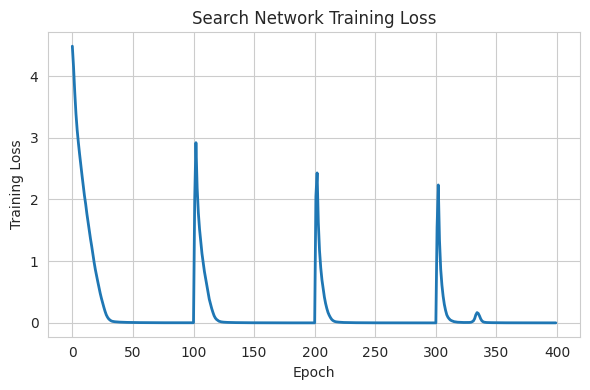

In [11]:
plt.figure(figsize=(6,4))
plt.plot(losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Search Network Training Loss")
plt.tight_layout()
plt.show()

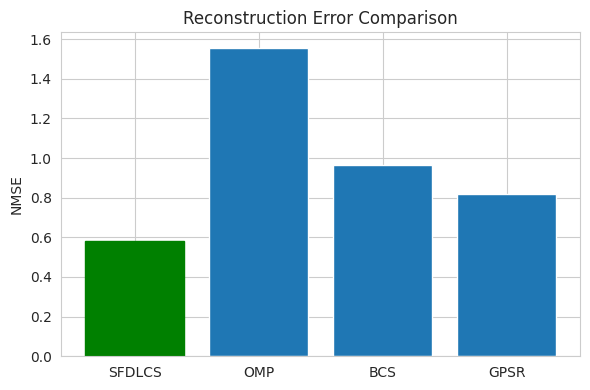

In [12]:
algs = list(results.keys())
nmse_vals = [results[a][0] for a in algs]

plt.figure(figsize=(6,4))
bars = plt.bar(algs, nmse_vals)

bars[0].set_color("green")  # highlight SFDLCS

plt.ylabel("NMSE")
plt.title("Reconstruction Error Comparison")
plt.tight_layout()
plt.show()

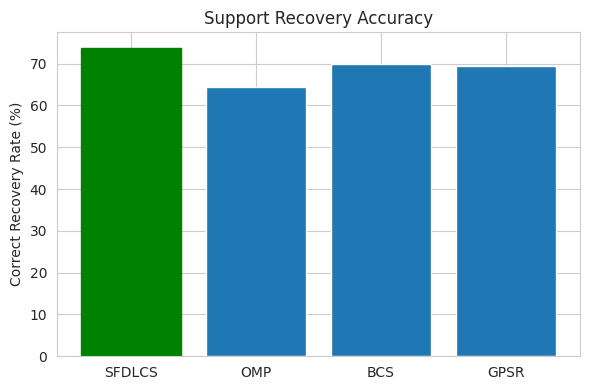

In [13]:
crr_vals = [results[a][1]*100 for a in algs]

plt.figure(figsize=(6,4))
bars = plt.bar(algs, crr_vals)
bars[0].set_color("green")

plt.ylabel("Correct Recovery Rate (%)")
plt.title("Support Recovery Accuracy")
plt.tight_layout()
plt.show()

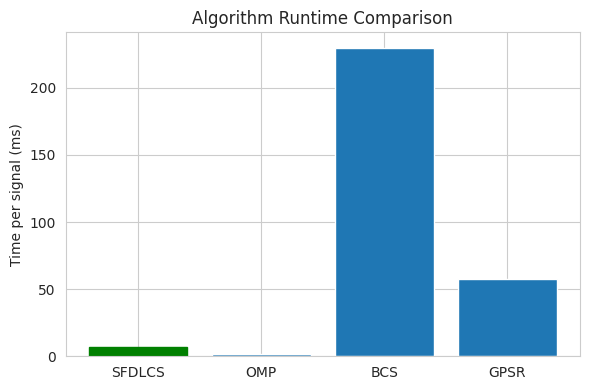

In [14]:
times = [results[a][2]*1000 for a in algs]

plt.figure(figsize=(6,4))
bars = plt.bar(algs, times)
bars[0].set_color("green")

plt.ylabel("Time per signal (ms)")
plt.title("Algorithm Runtime Comparison")
plt.tight_layout()
plt.show()

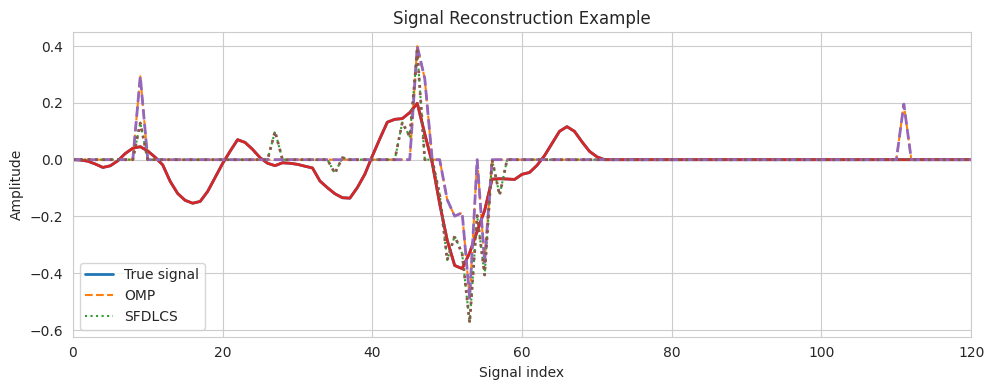

In [22]:
idx = 0

plt.figure(figsize=(10,4))
plt.plot(S_te[idx], label="True signal", linewidth=2)
plt.plot(OMP_all[idx], label="OMP", linestyle="--")
plt.plot(SF_all[idx], label="SFDLCS", linestyle=":")
plt.legend()
plt.xlabel("Signal index")
plt.ylabel("Amplitude")
plt.title("Signal Reconstruction Example")
plt.tight_layout()
plt.xlim(0,120)
plt.plot(S_te[idx], label="True", linewidth=2)
plt.plot(OMP_all[idx], '--', linewidth=2)
plt.plot(SF_all[idx], ':', linewidth=2)
plt.show()

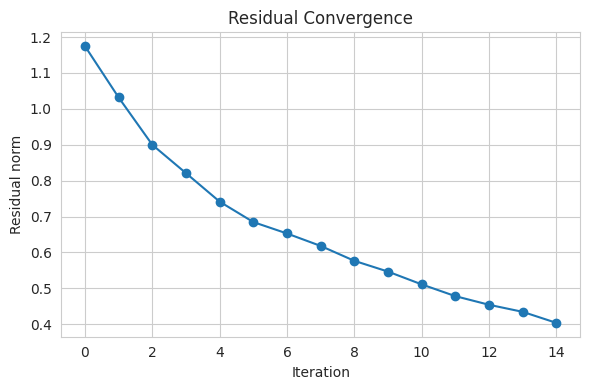

In [16]:
def residual_curve(y, PHI, net):
    r = y.copy()
    res = []

    for _ in range(K):
        res.append(np.linalg.norm(r))
        idx = np.argmax(np.abs(PHI.T @ r))
        col = PHI[:,idx]
        th = np.dot(col,r)/(np.dot(col,col)+1e-10)
        r = r - col*th

    return res

curve = residual_curve(Y_te[0], PHI, search_net)

plt.figure(figsize=(6,4))
plt.plot(curve, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Residual norm")
plt.title("Residual Convergence")
plt.tight_layout()
plt.show()

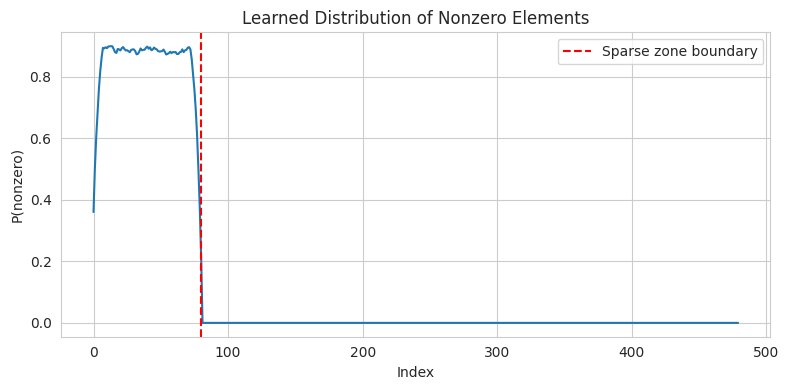

In [21]:
plt.figure(figsize=(8,4))
plt.plot(dec_prob_nn)
plt.axvline(SZ, color="red", linestyle="--", label="Sparse zone boundary")
plt.xlabel("Index")
plt.ylabel("P(nonzero)")
plt.title("Learned Distribution of Nonzero Elements")
plt.legend()

plt.tight_layout()
plt.show()

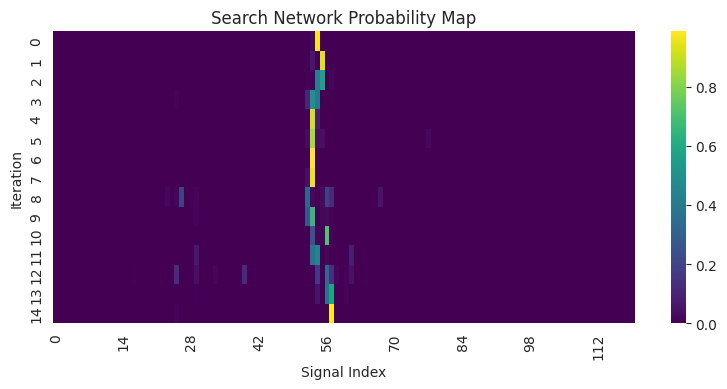

In [23]:
plt.figure(figsize=(8,4))
sns.heatmap(probs, cmap="viridis")
plt.xlabel("Signal Index")
plt.ylabel("Iteration")
plt.title("Search Network Probability Map")
plt.tight_layout()
plt.xlim(0,120)
plt.show()

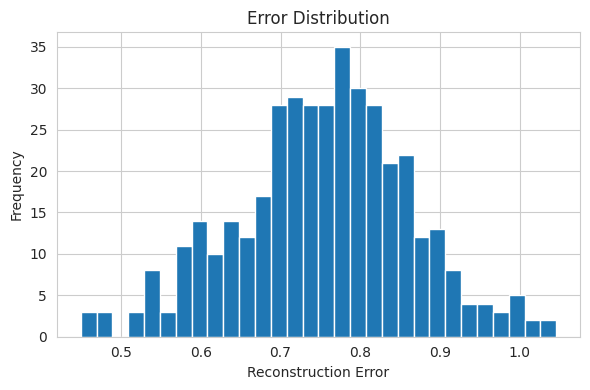

In [19]:
errors = np.linalg.norm(SF_all - S_te, axis=1)

plt.figure(figsize=(6,4))
plt.hist(errors, bins=30)
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()

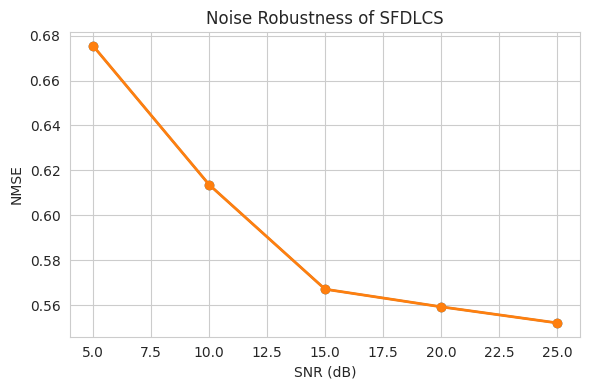

In [24]:
snrs = [5,10,15,20,25]
nmse_curve = []

for snr in snrs:

    Y_temp = add_noise(PHI @ S_te.T, snr, 99).T

    preds = np.array([
        sfdlcs_recon(Y_temp[i],PHI,search_net,dec_prob_nn,K)
        for i in range(100)
    ])

    nmse_curve.append(nmse(S_te[:100], preds))

plt.figure(figsize=(6,4))
plt.plot(snrs, nmse_curve, marker='o')
plt.xlabel("SNR (dB)")
plt.ylabel("NMSE")
plt.title("Noise Robustness of SFDLCS")
plt.tight_layout()
plt.plot(snrs, nmse_curve, marker='o', linewidth=2)
plt.show()

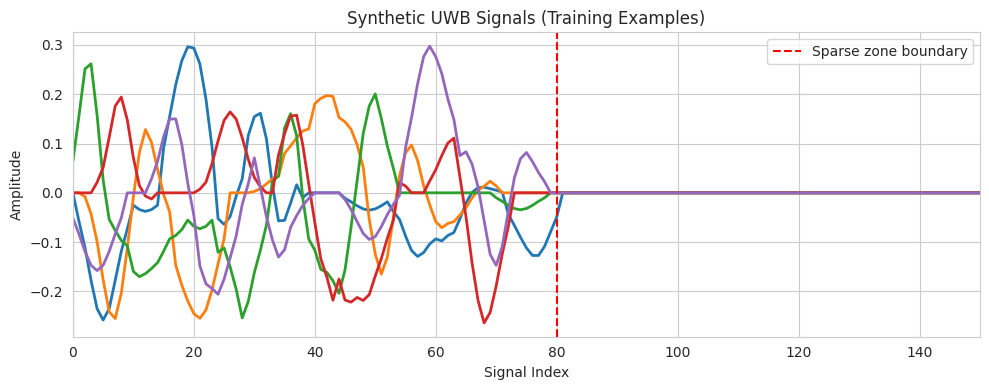

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for i in range(5):
    plt.plot(S_tr[i], linewidth=2)

plt.axvline(SZ, color='red', linestyle='--', label='Sparse zone boundary')
plt.title("Synthetic UWB Signals (Training Examples)")
plt.xlabel("Signal Index")
plt.ylabel("Amplitude")
plt.xlim(0,150)
plt.legend()
plt.tight_layout()
plt.show()

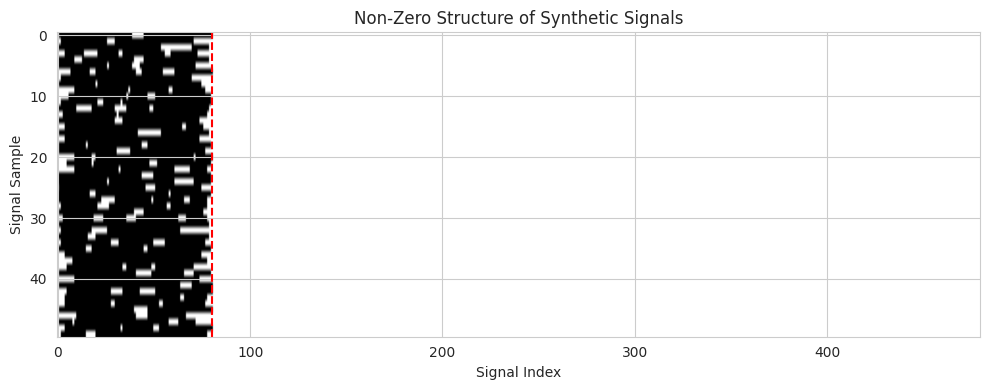

In [27]:
nz = (S_tr != 0).astype(int)

plt.figure(figsize=(10,4))
plt.imshow(nz[:50], aspect='auto', cmap='gray_r')
plt.axvline(SZ, color='red', linestyle='--')
plt.title("Non-Zero Structure of Synthetic Signals")
plt.xlabel("Signal Index")
plt.ylabel("Signal Sample")
plt.tight_layout()
plt.show()

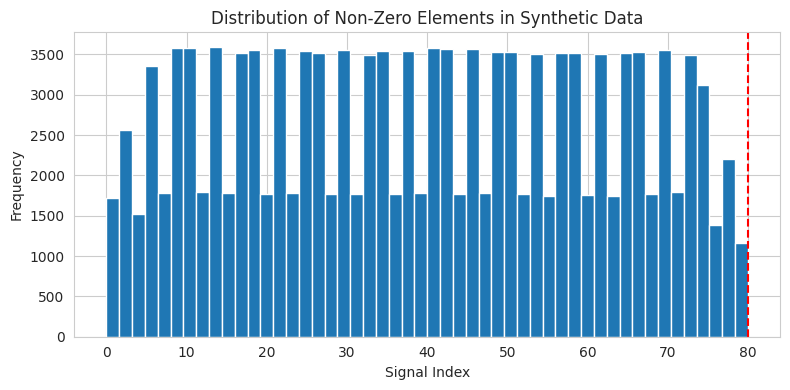

In [28]:
positions = np.where(S_tr != 0)[1]

plt.figure(figsize=(8,4))
plt.hist(positions, bins=50)
plt.axvline(SZ, color='red', linestyle='--')
plt.title("Distribution of Non-Zero Elements in Synthetic Data")
plt.xlabel("Signal Index")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

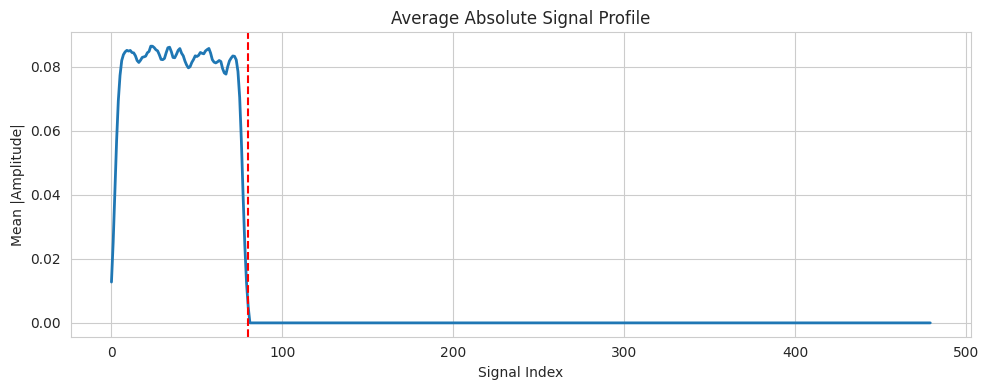

In [29]:
plt.figure(figsize=(10,4))
plt.plot(np.mean(np.abs(S_tr), axis=0), linewidth=2)
plt.axvline(SZ, color='red', linestyle='--')
plt.title("Average Absolute Signal Profile")
plt.xlabel("Signal Index")
plt.ylabel("Mean |Amplitude|")
plt.tight_layout()
plt.show()

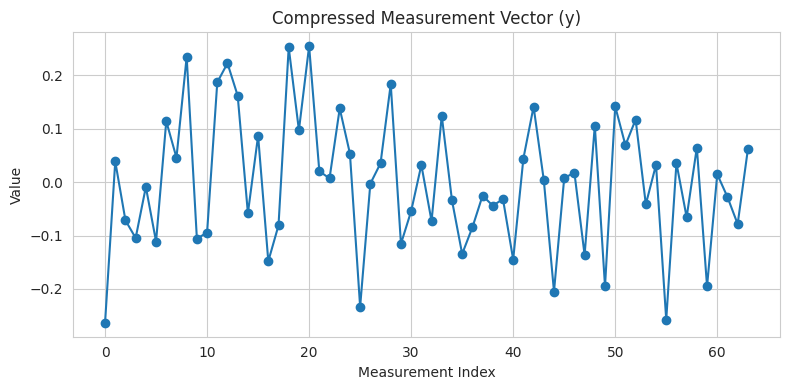

In [30]:
plt.figure(figsize=(8,4))
plt.plot(Y_tr[0], marker='o')
plt.title("Compressed Measurement Vector (y)")
plt.xlabel("Measurement Index")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

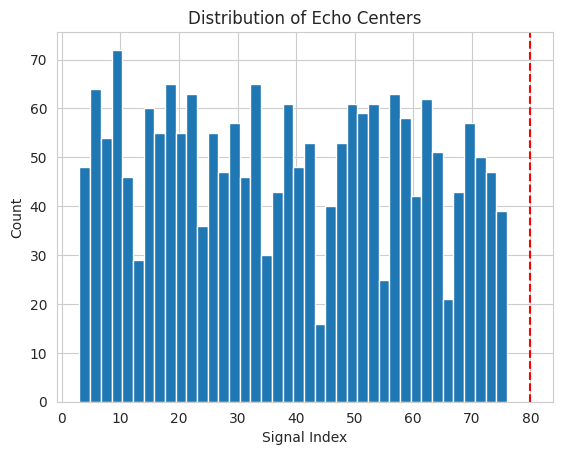

In [31]:
positions = np.argmax(np.abs(S_tr), axis=1)

plt.hist(positions, bins=40)
plt.axvline(SZ, color='red', linestyle='--')
plt.title("Distribution of Echo Centers")
plt.xlabel("Signal Index")
plt.ylabel("Count")
plt.show()

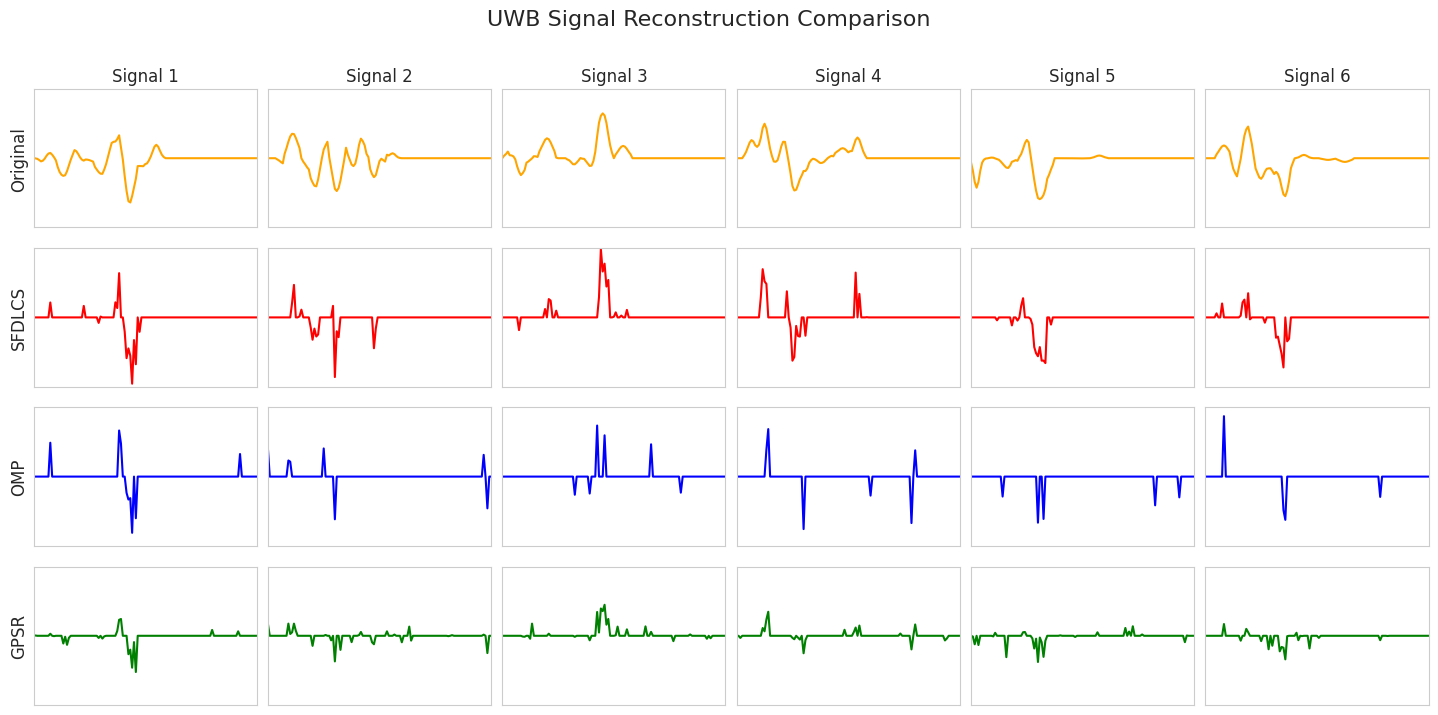

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# number of signals to visualize
NUM_SIGNALS = 6

# rows: original / SFDLCS / OMP / GPSR
NUM_ROWS = 4

fig, axes = plt.subplots(NUM_ROWS, NUM_SIGNALS, figsize=(18,8))

for col in range(NUM_SIGNALS):

    idx = col

    true_sig = S_te[idx]
    sfdlcs   = SF_all[idx]
    omp_sig  = OMP_all[idx]
    gps_sig  = GPS_all[idx]

    signals = [
        (true_sig, 'orange'),
        (sfdlcs,   'red'),
        (omp_sig,  'blue'),
        (gps_sig,  'green')
    ]

    for row, (sig, color) in enumerate(signals):

        axes[row, col].plot(sig, color=color, linewidth=1.5)

        # zoom into active region
        axes[row, col].set_xlim(0,120)

        # consistent amplitude scale
        axes[row, col].set_ylim(-0.6,0.6)

        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

# row labels
axes[0,0].set_ylabel("Original", fontsize=12)
axes[1,0].set_ylabel("SFDLCS", fontsize=12)
axes[2,0].set_ylabel("OMP", fontsize=12)
axes[3,0].set_ylabel("GPSR", fontsize=12)

# column titles
for col in range(NUM_SIGNALS):
    axes[0,col].set_title(f"Signal {col+1}", fontsize=12)

plt.subplots_adjust(wspace=0.05, hspace=0.15)
plt.suptitle("UWB Signal Reconstruction Comparison", fontsize=16)
axes[row,col].set_xlim(0,120)

plt.show()